### this notebook explores findings used in the Seattle, What are you Reading? analysis

In [1]:
##setup env
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from matplotlib import cm
import matplotlib.pyplot as plt
from rapidfuzz import process, fuzz
import re
from collections import Counter
from datetime import date


processed_dir = '/Users/audriswong/data-portfolio/projects/seattle-checkouts/data/processed'
figure_output_dir = '/Users/audriswong/data-portfolio/projects/seattle-checkouts/analyses and outputs/reading_trends/figures/'

#import data
book_checkouts = pd.read_parquet(f'{processed_dir}/book_checkouts.parquet').rename(columns={'title_clean': 'title'}) 
ebook_checkouts = pd.read_parquet(f'{processed_dir}/ebook_checkouts.parquet').rename(columns={'title_clean': 'title'})

In [2]:
# Total checkouts and distinct titles per month for physical books
book_monthly = book_checkouts.groupby('month_date').agg(
    total_checkouts=('checkouts', 'sum'),
    distinct_titles=('title', 'nunique'),
    distinct_works=('work_key', 'nunique')
).reset_index()
book_monthly['checkouts'] = pd.to_numeric(book_monthly['total_checkouts'])
book_monthly = book_monthly.sort_values('month_date')

# Total checkouts and distinct titles per month for ebooks
ebook_monthly = ebook_checkouts.groupby('month_date').agg(
    total_checkouts=('checkouts', 'sum'),
    distinct_titles=('title', 'nunique'),
    distinct_works=('work_key', 'nunique')
).reset_index()
ebook_monthly['total_checkouts'] = pd.to_numeric(ebook_monthly['total_checkouts'])
ebook_monthly = ebook_monthly.sort_values('month_date')

# Compute total distinct works across both formats per month
combined_works = (book_monthly[['month_date', 'distinct_works']]
                  .merge(ebook_monthly[['month_date', 'distinct_works']], 
                         on='month_date', suffixes=('_book', '_ebook')))
combined_works['total_works'] = combined_works['distinct_works_book'] + combined_works['distinct_works_ebook']
combined_works['pct_book']    = combined_works['distinct_works_book']  / combined_works['total_works'] * 100
combined_works['pct_ebook']   = combined_works['distinct_works_ebook'] / combined_works['total_works'] * 100

# Compute total checkouts
combined_checkouts = (book_monthly[['month_date', 'total_checkouts']]
                      .merge(ebook_monthly[['month_date', 'total_checkouts']],
                             on='month_date', suffixes=('_book', '_ebook')))
combined_checkouts['total']     = combined_checkouts['total_checkouts_book'] + combined_checkouts['total_checkouts_ebook']
combined_checkouts['pct_book']  = combined_checkouts['total_checkouts_book']  / combined_checkouts['total'] * 100
combined_checkouts['pct_ebook'] = combined_checkouts['total_checkouts_ebook'] / combined_checkouts['total'] * 100


# Calculate average checkouts per title
book_monthly['avg_checkouts_per_title'] = book_monthly['total_checkouts'] / book_monthly['distinct_titles']
ebook_monthly['avg_checkouts_per_title'] = ebook_monthly['total_checkouts'] / ebook_monthly['distinct_titles']
book_monthly['avg_checkouts_per_work'] = book_monthly['total_checkouts'] / book_monthly['distinct_works']
ebook_monthly['avg_checkouts_per_work'] = ebook_monthly['total_checkouts'] / ebook_monthly['distinct_works']

#### How has the checkout mix between physical vs digital titles changed over time?
##### Total monthly checkouts declined during COVID-19 library branch closures (March–August 2020) and physical checkouts reaching near zero.  Digital checkout volume partially offset the loss but did not fully recover total checkout volume. 
##### Post-reopening recovery was gradual, with total combined checkout volume returning to pre-COVID levels by mid-2021. 
##### By 2023, total volume had stabilized and digital checkouts consistently exceed physical checkouts.
##### Physical books made up ~72% of total checkouts in 2017, declining slowly to ~64% by early 2020. COVID branch closures moved virtually all checkouts online to digital. After branches reopened in August 2020, physical checkouts recovered steadily, catching up with with digital by July 2021. Both formats remained roughly equal until September 2023, after which digital consistently exceeds physical checkouts. As of 2025, the split is approximately 46% physical / 54% digital.

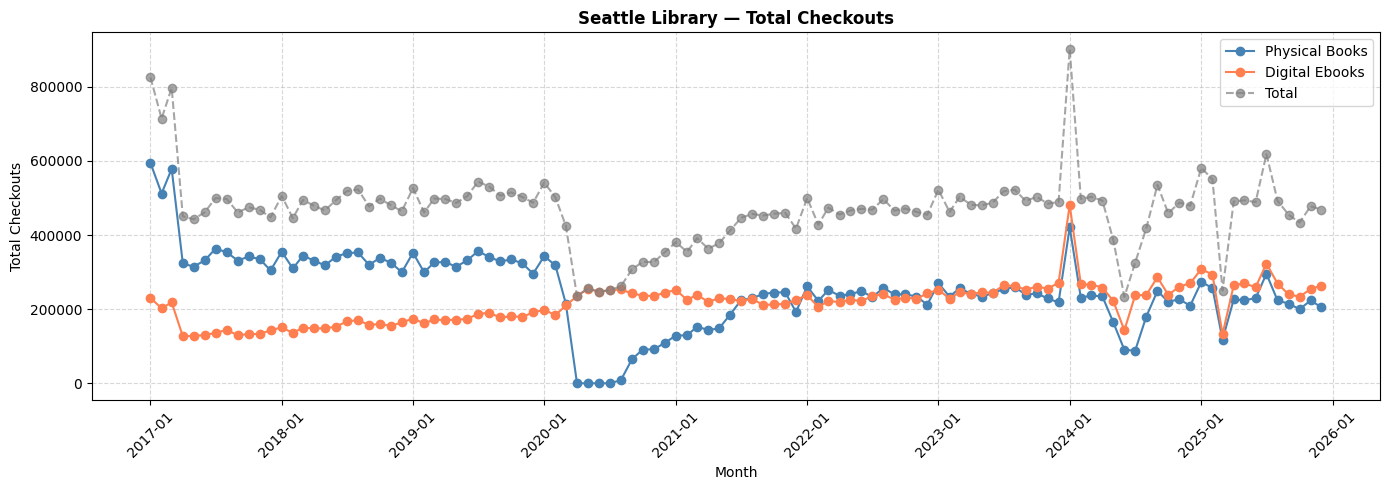

✅ Total Checkouts saved


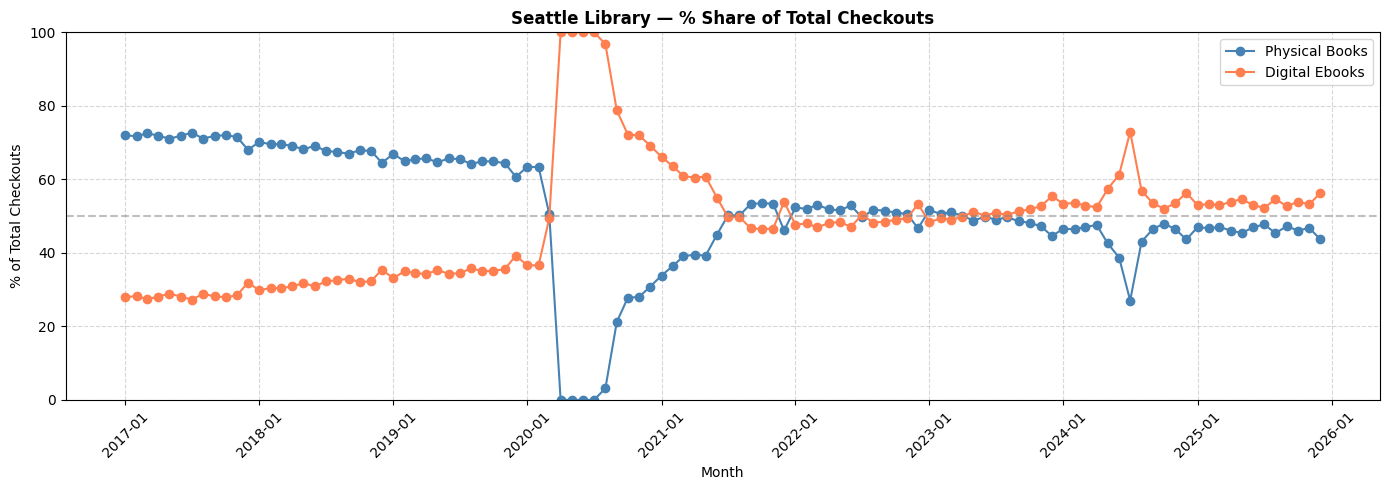

✅ % Share of Total Checkouts saved


In [3]:
#Plot digital + physical book checkout trends over time since 2017
# Plot Total Checkouts
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(book_monthly['month_date'], book_monthly['total_checkouts'],
        marker='o', label='Physical Books', color='steelblue')
ax.plot(ebook_monthly['month_date'], ebook_monthly['total_checkouts'],
        marker='o', label='Digital Ebooks', color='coral')
# Combined total line
ax.plot(combined_checkouts['month_date'], combined_checkouts['total'],
        marker='o', label='Total', color='grey', linestyle='--', alpha=0.7)
ax.set_title('Seattle Library — Total Checkouts', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Checkouts')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{figure_output_dir}/total_checkouts.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Total Checkouts saved")

# Plot % Share of Total Checkouts
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(combined_checkouts['month_date'], combined_checkouts['pct_book'],
        marker='o', label='Physical Books', color='steelblue')
ax.plot(combined_checkouts['month_date'], combined_checkouts['pct_ebook'],
        marker='o', label='Digital Ebooks', color='coral')
ax.axhline(50, color='grey', linestyle='--', alpha=0.5)
ax.set_title('Seattle Library — % Share of Total Checkouts', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('% of Total Checkouts')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{figure_output_dir}/pct_share_total_checkouts.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ % Share of Total Checkouts saved")

In [4]:
# define function to extract genre from keywords and test performance
# See a sample of raw subjects values
print("Sample subjects values:")
book_checkouts['subjects'].dropna().sample(20).tolist()

# Check null rate
null_rate = book_checkouts['subjects'].isna().mean() * 100
print(f"Null subjects: {null_rate:.1f}%")

# See most common subject strings
print("\nMost common subjects:")
book_checkouts['subjects'].value_counts().head(20)

# keyword -> genre mapping
genre_keywords = {
    'Mystery/Thriller': ['mystery', 'detective', 'crime', 'thriller', 'suspense'],
    'Science Fiction':  ['science fiction', 'sci-fi'],
    'Fantasy':          ['fantasy'],
    'Romance':          ['romance', 'love stories'],
    'Horror':           ['horror'],
    'Historical':       ['historical fiction', 'history'],
    'Biography/Memoir': ['biography', 'memoir', 'autobiography'],
    'Self-Help':        ['self-help', 'personal development', 'motivation', 'success'],
    'Cooking':          ['cooking', 'cookbooks', 'baking', 'vegan cooking', 'food'],
    'Poetry':           ['poetry'],
    'Graphic Novel':    ['graphic novels', 'comics', 'manga'],
    'Juvenile':         ['juvenile', 'childrens', "children's", 'picture book', 'young adult'],
    'Crafts':           ['knitting', 'quilting', 'sewing', 'crafts'],
    'Health/Wellness':  ['health', 'wellness', 'fitness', 'diet', 'medicine'],
    'Business':         ['business', 'economics', 'finance', 'management'],
    'Science/Nature':   ['science', 'nature', 'animals', 'dinosaurs'],
    'Religion':         ['religion', 'spiritual', 'christian', 'bible'],
    'Travel':           ['travel', 'geography'],
    'Art/Design':       ['art', 'interior decoration', 'design', 'photography'],
    'Humor':            ['humor'],
    'Nonfiction':       ['nonfiction'],
    'Fiction':          ['fiction', 'novel', 'short stories', 'literature'],
}

def extract_genre(subjects):
    if pd.isna(subjects):
        return 'Unknown'
    subjects_lower = str(subjects).lower()
    for genre, keywords in genre_keywords.items():
        if any(kw in subjects_lower for kw in keywords):
            return genre
    return 'Other'

# Extract physical and digital book genres from keywords
book_checkouts['genre'] = book_checkouts['subjects'].apply(extract_genre)
ebook_checkouts['genre'] = ebook_checkouts['subjects'].apply(extract_genre)

# Check extraction coverage
print("Physical Books - Genre distribution:")
print(book_checkouts['genre'].value_counts())

print(f"\nUnclassified (Other/Unknown): {(book_checkouts['genre'].isin(['Other','Unknown'])).mean()*100:.1f}%")

# Spot check 'Other' genre to see what's being missed
print("\nPhysical Books - Sample unclassified subjects:")
book_checkouts[book_checkouts['genre'] == 'Other']['subjects'].value_counts().head(20)

print("Digital EBooks - Genre distribution:")
print(ebook_checkouts['genre'].value_counts())

print(f"\nUnclassified (Other/Unknown): {(ebook_checkouts['genre'].isin(['Other','Unknown'])).mean()*100:.1f}%")

# Spot check 'Other' to see what's being missed
print("\nDigital EBooks - Sample unclassified subjects:")
ebook_checkouts[ebook_checkouts['genre'] == 'Other']['subjects'].value_counts().head(20)

Sample subjects values:
Null subjects: 1.5%

Most common subjects:
Physical Books - Genre distribution:
genre
Juvenile            2561198
Other               1379402
Mystery/Thriller     834843
Historical           802059
Fiction              459614
Biography/Memoir     459455
Fantasy              386871
Cooking              384427
Graphic Novel        380479
Science Fiction      273977
Art/Design           236081
Romance              215858
Unknown              138366
Poetry               110773
Business             110342
Travel               103777
Health/Wellness       94219
Religion              86051
Science/Nature        80169
Horror                63110
Humor                 57999
Crafts                56152
Self-Help             52039
Nonfiction             1970
Name: count, dtype: int64

Unclassified (Other/Unknown): 16.3%

Physical Books - Sample unclassified subjects:
Digital EBooks - Genre distribution:
genre
Mystery/Thriller    1489932
Juvenile             912543
Romance 

subjects
Beginning Reader                   489
Comic and Graphic Books            166
Essays                              21
Mathematics                         10
Family & Relationships               8
Children                             7
NA                                   2
Self-Improvement                     2
Military                             2
New Age                              1
Sociology, Sports & Recreations      1
Biology                              1
Name: count, dtype: int64

In [5]:
#define genre mapping function for top 10% of works by monthly popularity
def top200_genre_breakdown(df, year_col='checkoutyear', month_col='checkoutmonth'):
    results = []
    
    for (year, month), group in df.groupby([year_col, month_col]):
        # Get top 200 works by checkout volume
        top200 = (group.groupby('work_key')
                  .agg(total_checkouts=('checkouts', 'sum'),
                       genre=('genre', 'first'))
                  .reset_index()
                  .sort_values('total_checkouts', ascending=False)
                  .head(200))
        
        # Genre breakdown of those top 200
        genre_breakdown = (top200.groupby('genre')
                           .agg(num_works=('work_key', 'count'),
                                total_checkouts=('total_checkouts', 'sum'))
                           .reset_index())
        genre_breakdown['pct_of_top200_works']     = (genre_breakdown['num_works'] / 200 * 100).round(1)
        genre_breakdown['pct_of_top200_checkouts'] = (genre_breakdown['total_checkouts'] / genre_breakdown['total_checkouts'].sum() * 100).round(1)
        genre_breakdown['checkoutyear']  = year
        genre_breakdown['checkoutmonth'] = month
        
        results.append(genre_breakdown)
    
    return pd.concat(results, ignore_index=True).sort_values(['checkoutyear', 'checkoutmonth', 'pct_of_top200_checkouts'], ascending=[True, True, False])

# extract genres from top 200 monthly books, ebooks
book_top200_genre  = top200_genre_breakdown(book_checkouts)
ebook_top200_genre = top200_genre_breakdown(ebook_checkouts)

# Count distinct genres represented per month for each format
book_genres_per_month  = book_top200_genre.groupby('checkoutmonth')['genre'].nunique()
ebook_genres_per_month = ebook_top200_genre.groupby('checkoutmonth')['genre'].nunique()

# Print performance statistics (# median, mean number of genres represented in top 10% of monthly checkouts)
print("📚 Physical Books — Genres in Top 10% per Month")
print(f"  Median: {book_genres_per_month.median():.1f}")
print(f"  Mean:   {book_genres_per_month.mean():.1f}")

print("\n📱 Digital Ebooks — Genres in Top 10% per Month")
print(f"  Median: {ebook_genres_per_month.median():.1f}")
print(f"  Mean:   {ebook_genres_per_month.mean():.1f}")

📚 Physical Books — Genres in Top 10% per Month
  Median: 23.0
  Mean:   23.0

📱 Digital Ebooks — Genres in Top 10% per Month
  Median: 17.0
  Mean:   17.1


#### How have different physical book genres changed in popularity over time?
##### Since the post-COVID reopening (June 2020), Fiction, Historical, and Biography/Memoir have dominated the top 3 in popularity. 
##### All genres collapsed during COVID closures except Juvenile, confirming that libraries remained a critical reading resource for children.

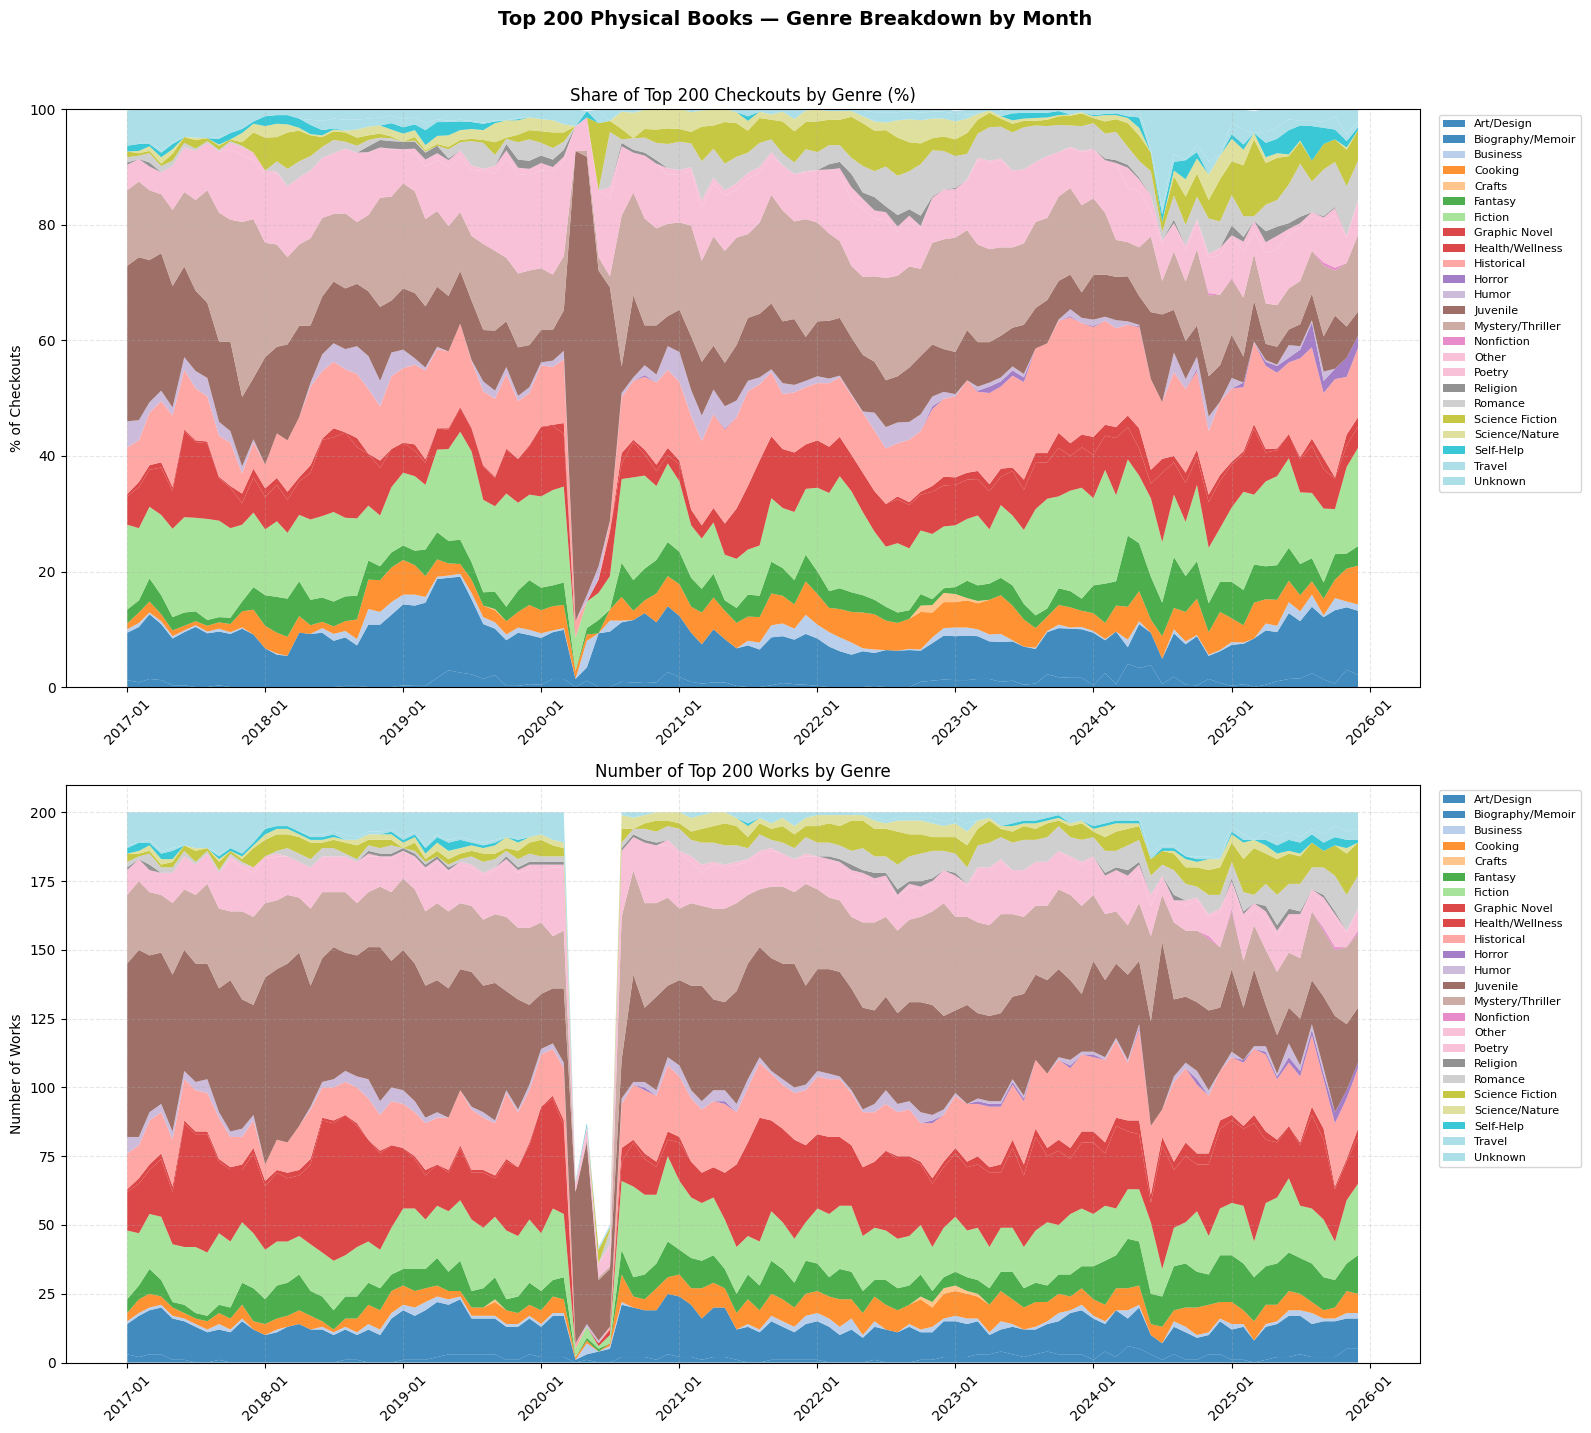

✅ Chart saved to outputs/figures/


In [6]:
#shared color map for plotting
all_genres = sorted(set(book_top200_genre['genre'].unique()) | set(ebook_top200_genre['genre'].unique()))
genre_colors = dict(zip(all_genres, cm.tab20(np.linspace(0, 1, len(all_genres)))))

# plot physical books
# Create month_date for plotting
book_top200_genre['month_date'] = pd.to_datetime(
    book_top200_genre['checkoutyear'].astype(str) + '-' +
    book_top200_genre['checkoutmonth'].astype(str).str.zfill(2) + '-01'
)

# Pivot for stacked area chart — % of top 200 checkouts by genre per month
book_genre_pivot = book_top200_genre.pivot_table(
    index='month_date',
    columns='genre',
    values='pct_of_top200_checkouts',
    aggfunc='sum'
).fillna(0).sort_index()

# Pull in genre + colors from preset color map
genres = book_genre_pivot.columns.tolist()
colors = [genre_colors[g] for g in genres]


# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle('Top 200 Physical Books — Genre Breakdown by Month',
             fontsize=14, fontweight='bold', y=1.02)

# Stacked area chart — % of checkouts
axes[0].stackplot(book_genre_pivot.index,
                  [book_genre_pivot[g] for g in genres],
                  labels=genres,
                  colors=colors,
                  alpha=0.85)
axes[0].set_title('Share of Top 200 Checkouts by Genre (%)')
axes[0].set_ylabel('% of Checkouts')
axes[0].set_ylim(0, 100)
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Stacked area chart — number of works
book_genre_pivot_works = book_top200_genre.pivot_table(
    index='month_date',
    columns='genre',
    values='num_works',
    aggfunc='sum'
).fillna(0).sort_index()

axes[1].stackplot(book_genre_pivot_works.index,
                  [book_genre_pivot_works[g] for g in genres],
                  labels=genres,
                  colors=colors,
                  alpha=0.85)
axes[1].set_title('Number of Top 200 Works by Genre')
axes[1].set_ylabel('Number of Works')
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figure_output_dir}/top200_book_genre_breakdown.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/figures/")

#### Are there any differences in genre makeup of the top 10% of popular ebooks vs physical books?:
##### The top 10% most popular physical books spans 23 genres while popular ebooks spans 17, confirming that physical collections serve a broader range of reader interests. 
##### Ebook genres have shifted within the top 10 in terms of popularity, reflecting changing reader tastes. Romance grew from 10% -> 24% in July 2023, Fantasy grew from ~7% to a peak of 22% in March 2025, and Juvenile has grown to ~14% as of early 2025. 
##### These emerging genres displaced Nonfiction (19% in 2020, now <2%) and Biography/Memoir (15% in 2020, now ~5%), both of which were genre leaders during COVID in 2020. By comparison, popular physical book genre share is more stable across the same period.
##### The limited overlap in physical and digital top 3 genres suggests that each format serves readers with different genre interests, and that the two collections should be treated as complements rather than substitutes.

#### How have popular genres changed in digital vs physical prominence over time?
##### Digital Format growth: Fantasy, Romance (hypothesis: this reflects booktok/ romantasy boom increasing ebook demand
##### Physical Format growth: Cooking (while it was still popular prior to 2023), Historical

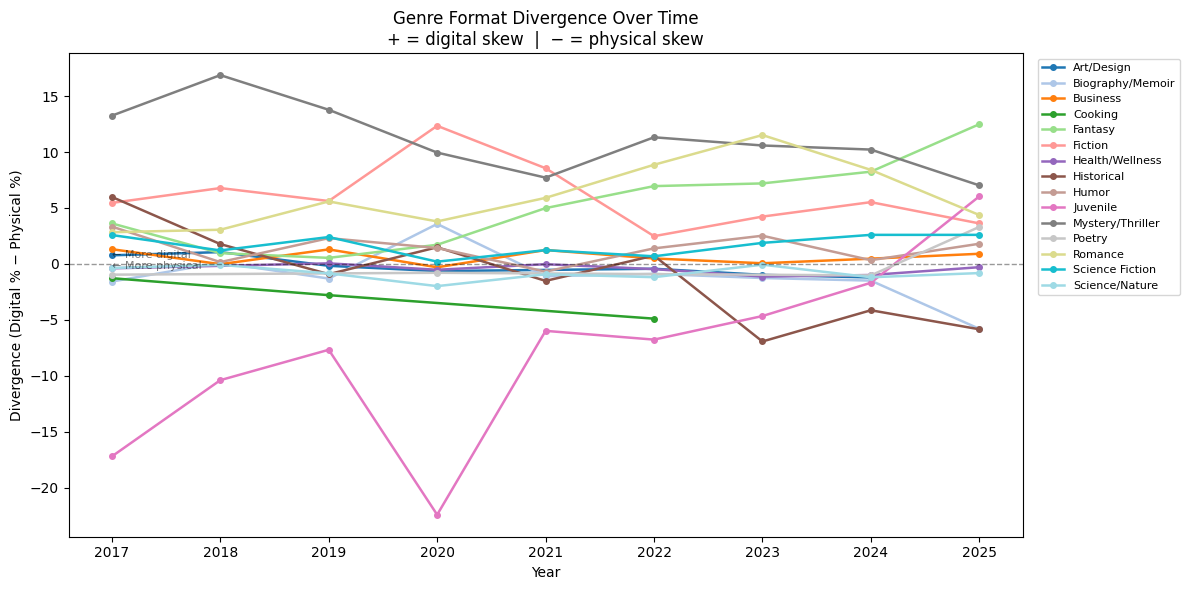

✅ Chart saved to outputs/figures/


In [7]:
years = sorted(book_top200_genre['checkoutyear'].unique())

all_years = []

for year in years:
    book_yr  = book_top200_genre[book_top200_genre['checkoutyear'] == year]
    ebook_yr = ebook_top200_genre[ebook_top200_genre['checkoutyear'] == year]

    book_avg  = book_yr.groupby('genre')['pct_of_top200_checkouts'].mean().rename('physical')
    ebook_avg = ebook_yr.groupby('genre')['pct_of_top200_checkouts'].mean().rename('digital')

    merged = pd.concat([book_avg, ebook_avg], axis=1).dropna()
    merged['combined']   = merged['physical'] + merged['digital']
    merged['divergence'] = merged['digital'] - merged['physical']
    merged['year']       = year
    merged = merged.reset_index()  # brings 'genre' back as a column

    all_years.append(merged)

divergence_df = pd.concat(all_years, ignore_index=True)

# Pick genres that appear in top 15 combined in ANY year
top_genres = (divergence_df.groupby('genre')['combined']
              .mean()
              .nlargest(15)
              .index)

plot_df = divergence_df[divergence_df['genre'].isin(top_genres)]

# Color: blue = digital skew, red = physical skew
import matplotlib.cm as cm
import numpy as np

genres = plot_df['genre'].unique()
colors = cm.tab20(np.linspace(0, 1, len(genres)))

fig, ax = plt.subplots(figsize=(12, 6))

for color, genre in zip(colors, genres):
    data = plot_df[plot_df['genre'] == genre].sort_values('year')
    ax.plot(data['year'], data['divergence'], marker='o', label=genre,
            color=color, linewidth=1.8, markersize=4)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax.annotate('← More physical', xy=(years[0], -0.5), fontsize=8, alpha=0.5)
ax.annotate('← More digital',  xy=(years[0],  0.5), fontsize=8, alpha=0.5)

ax.set_xlabel('Year')
ax.set_ylabel('Divergence (Digital % − Physical %)')
ax.set_title('Genre Format Divergence Over Time\n+ = digital skew  |  − = physical skew')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{figure_output_dir}/yearly_genre_format_divergence.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to outputs/figures/")

#### How long do popular books stay popular?  For example, do the top 10 most popular works stay in the top 10 in the second, third, etc. month?
##### Historically, top ebook titles stay in the top 10 for 3–7 consecutive months (median), with notable exceptions in 2018 and 2020.  By comparison, top physical book titles have a shorter popularity tenure, with a median of 1–3 consecutive months. 
##### Since 2024, both formats have converged to a median of 1 consecutive month in the top 10.  This shortening (especially for digital works) suggests patron interest in specific titles is becoming more volatile and shorter-lived. 
##### This might be caused by shortening social media discovery cycles (BookTok), which creates brief, intense spikes in patron interest that fade quickly, particularly for ebooks borrowed on the same devices used for social media.

In [8]:
# add ranking (based on volume of monthly checkouts) per work 

def works_with_monthly_rank(df, year_col='checkoutyear', month_col='checkoutmonth'):
    results = []
    for (year, month), group in df.groupby([year_col, month_col]):
        ranked = (group.groupby('work_key')
                .agg(total_checkouts=('checkouts', 'sum'),
                     genre=('genre', 'first'),
                     title=('title', 'first'),
                     creator=('creator_clean', 'first'),
                     month_date = ('month_date', 'first'))
                .reset_index()
                .sort_values('total_checkouts', ascending=False))
        ranked['month_checkout_rank'] = range(1, len(ranked) + 1)
        ranked['checkoutyear']  = year
        ranked['checkoutmonth'] = month
        results.append(ranked)
    return pd.concat(results, ignore_index=True)

book_ranked  = works_with_monthly_rank(book_checkouts)
ebook_ranked = works_with_monthly_rank(ebook_checkouts)

In [9]:
# define popularity tenure function, defined as number of consecutive months
# a work stays in the top 10 list
def max_consecutive_months(dates):
    """Given a series of month_dates, return the longest consecutive run in months"""
    if len(dates) == 0:
        return 0
    dates_sorted = sorted(pd.to_datetime(dates))
    max_run = 1
    current_run = 1
    for i in range(1, len(dates_sorted)):
        diff = (dates_sorted[i].year - dates_sorted[i-1].year) * 12 + \
               (dates_sorted[i].month - dates_sorted[i-1].month)
        if diff == 1:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 1
    return max_run

# Compute consecutive months in top 10 per physical book
book_consecutive = (book_ranked[book_ranked['month_checkout_rank'] <= 10]
                    .sort_values('month_date')
                    .groupby('work_key')
                    .agg(
                        max_consecutive=('month_date', max_consecutive_months),
                        genre=('genre', 'first'),
                        title=('title', 'first'),
                        entry_month=('checkoutmonth', 'first'),  # month book first entered top 10
                        entry_year=('checkoutyear', 'first')
                    )
                    .reset_index())

# Sort genres by median consecutive months descending
book_genre_order = (book_consecutive.groupby('genre')['max_consecutive']
               .median()
               .sort_values(ascending=False)
               .index.tolist())

# Compute consecutive months in top 10 per ebook
ebook_consecutive = (ebook_ranked[ebook_ranked['month_checkout_rank'] <= 10]
                    .sort_values('month_date')
                    .groupby('work_key')
                    .agg(
                        max_consecutive=('month_date', max_consecutive_months),
                        genre=('genre', 'first'),
                        title=('title', 'first'),
                        entry_month=('checkoutmonth', 'first'),  # month book first entered top 10
                        entry_year=('checkoutyear', 'first')
                    )
                    .reset_index())

# Sort genres by median consecutive months descending
ebook_genre_order = (ebook_consecutive.groupby('genre')['max_consecutive']
               .median()
               .sort_values(ascending=False)
               .index.tolist())

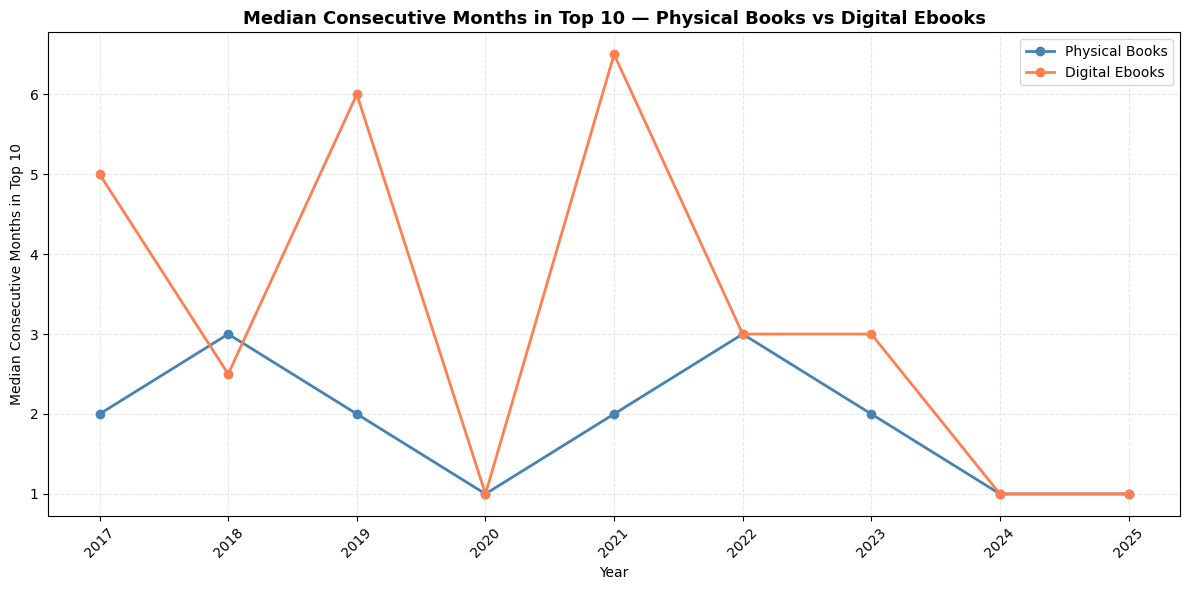

In [10]:
# Plot consecutive months in top 10 aggregated (median) across all years
# Compute median consecutive months by year for books and ebooks
book_yearly   = (book_consecutive.groupby('entry_year')['max_consecutive']
                 .median().reset_index()
                 .rename(columns={'max_consecutive': 'median_consecutive'}))

ebook_yearly  = (ebook_consecutive.groupby('entry_year')['max_consecutive']
                 .median().reset_index()
                 .rename(columns={'max_consecutive': 'median_consecutive'}))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(book_yearly['entry_year'],  book_yearly['median_consecutive'],
        marker='o', linewidth=2, label='Physical Books', color='steelblue')
ax.plot(ebook_yearly['entry_year'], ebook_yearly['median_consecutive'],
        marker='o', linewidth=2, label='Digital Ebooks', color='coral')

ax.set_title('Median Consecutive Months in Top 10 — Physical Books vs Digital Ebooks',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Consecutive Months in Top 10')
ax.set_xticks(sorted(book_yearly['entry_year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figure_output_dir}/median_survival_by_year.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
##what are the outlier books with 20+ mo staying power?

print(f"=== Most Popular Physical Books by Top 10 List staying power ===")
print(book_consecutive.sort_values('max_consecutive', ascending = False).head(10))

print(f"\n === Most Popular EBooks by Top 10 List staying power ===")
print(ebook_consecutive.sort_values('max_consecutive', ascending = False).head(10))

=== Most Popular Physical Books by Top 10 List staying power ===
                                              work_key  max_consecutive  \
163             LESSONS IN CHEMISTRY || GARMUS, BONNIE               13   
408                THE VANISHING HALF || BENNETT, BRIT               13   
452            WHERE THE CRAWDADS SING || OWENS, DELIA               11   
53                         BECOMING || OBAMA, MICHELLE               10   
155               KLARA AND THE SUN || ISHIGURO, KAZUO                9   
76   CASTE : THE ORIGINS OF OUR DISCONTENTS || WILK...                9   
131  HILLBILLY ELEGY : A MEMOIR OF A FAMILY AND CUL...                8   
354                  THE LIBRARY BOOK || ORLEAN, SUSAN                8   
103              EDUCATED : A MEMOIR || WESTOVER, TARA                8   
407  THE UNDERGROUND RAILROAD : A NOVEL || WHITEHEA...                8   

                genre                                              title  \
163        Historical            

#### What's the overlap in top 10 list titles between digital ebooks and physical books?  Has this changed over time?
##### The overlap between the top 10 physical books and the top 10 ebooks has dropped from 15% -> 1% since 2023.
##### This divergence confirms that physical and digital formats are increasingly serving reader communities with different tastes.

In [12]:
# Match Top 10 Books against Ebook Checkouts to measure overlap in popularity
# Matching criteria: 
## Fuzzy Match on closest author
## Fuzzy Match on closest title AND then return title with the highest count of title words directly matched (minimum 1)
# more details on matching algorithm development found in 05_title_matching.ipynb file

#rank add monthly checkout ranking per work to all titles
def works_with_monthly_rank(df, year_col='checkoutyear', month_col='checkoutmonth'):
    results = []
    for (year, month), group in df.groupby([year_col, month_col]):
        ranked = (group.groupby('work_key')
                .agg(total_checkouts=('checkouts', 'sum'),
                     genre=('genre', 'first'),
                     title=('title', 'first'),
                     creator=('creator_clean', 'first'),
                     month_date = ('month_date', 'first'))
                .reset_index()
                .sort_values('total_checkouts', ascending=False))
        ranked['month_checkout_rank'] = range(1, len(ranked) + 1)
        ranked['checkoutyear']  = year
        ranked['checkoutmonth'] = month
        results.append(ranked)
    return pd.concat(results, ignore_index=True)

book_ranked  = works_with_monthly_rank(book_checkouts)
ebook_ranked = works_with_monthly_rank(ebook_checkouts)

In [13]:
# Define matching functions
##  Fuzzy Match on closest author, then fuzzy match on closest title, then return title with ≥ 80% title overlap
##  generalize matching logic to be direction agnostic: handle ebook -> book, book -> ebook
def fuzzy_cross_rank(origin_df, destination_df,
                     origin_label='origin', destination_label='destination',
                     origin_rank_cutoff=10, destination_rank_cutoff=None,
                     author_threshold=70, min_substring_len=3,
                     overlap_threshold=0.8,
                     extra_destination_fields=None):  # ← added here
    """
    Direction-agnostic fuzzy matching function.
    Matches titles in origin_df to closest title in destination_df.
    Title matching criterion: >= overlap_threshold word overlap (shorter → longer).

    Parameters:
        origin_df                : DataFrame being iterated
        destination_df           : DataFrame being searched
        origin_label             : label for origin columns (e.g. 'book' or 'ebook')
        destination_label        : label for destination columns (e.g. 'ebook' or 'book')
        origin_rank_cutoff       : only consider origin titles ranked <= this value
        destination_rank_cutoff  : only search destination titles ranked <= this value (None = no filter)
        author_threshold         : minimum fuzzy author score to consider
        min_substring_len        : minimum word length to be considered meaningful
        overlap_threshold        : minimum word overlap fraction to accept a title match (default 0.8)
        extra_destination_fields : optional list of column names to pull from destination row
                                   e.g. ['list_name', 'display_name']. Defaults to None.
    """

    noise = {'a', 'an', 'the', 'of', 'in', 'and', 'or', 'to', 'by', 'for',
             'novel', 'memoir', 'story', 'book', 'vol', 'volume', 'series',
             'pick', 'winner', 'prize', 'club', 'read', 'with', 'jenna',
             'oprah', 'reese', 'pulitzer', 'collection', 'continuing'}

    def clean_author(author):
        author = re.sub(r'\(.*?\)', '', str(author))
        author = re.sub(r',?\s*(JR|SR|II|III|IV)\.?', '', author, flags=re.IGNORECASE)
        author = re.sub(r',?\s*\d{4}-?(\d{4})?', '', author)
        return author.strip()

    def meaningful_words(title, author=None):
        words = set(re.sub(r'[^a-z0-9\s]', ' ', str(title).lower()).split())
        author_words = set(re.sub(r'[^a-z0-9\s]', ' ', str(author).lower()).split()) if author else set()
        return [w for w in words
                if w not in noise
                and len(w) >= min_substring_len
                and w not in author_words]

    def word_overlap(words_a, words_b):
        if not words_a or not words_b:
            return 0.0
        shorter = words_a if len(words_a) <= len(words_b) else words_b
        longer  = ' '.join(words_b if len(words_a) <= len(words_b) else words_a)
        matched = [w for w in shorter if w in longer]
        return len(matched) / len(shorter)

    results = []

    for (year, month), origin_group in (
        origin_df[origin_df['month_checkout_rank'] <= origin_rank_cutoff]
        .groupby(['checkoutyear', 'checkoutmonth'])
    ):
        dest_month = destination_df[
            (destination_df['checkoutyear'] == year) &
            (destination_df['checkoutmonth'] == month)
        ]
        if destination_rank_cutoff is not None:
            dest_month = dest_month[dest_month['month_checkout_rank'] <= destination_rank_cutoff]

        dest_month   = dest_month.drop_duplicates('title').copy()
        dest_authors = dest_month['creator'].tolist()

        for _, origin_row in origin_group.iterrows():
            origin_author_clean = clean_author(origin_row['creator'])
            origin_words        = meaningful_words(origin_row['title'], origin_row['creator'])

            # Step 1 — fuzzy author match
            author_candidates = process.extract(origin_author_clean, dest_authors,
                                                scorer=fuzz.token_sort_ratio, limit=10)
            passing_authors = [(score, idx) for _, score, idx in author_candidates
                               if score >= author_threshold]

            best_match = best_title_score = best_author_score = best_matched_words = best_overlap = None

            if passing_authors:
                title_candidates = []
                for author_score, idx in passing_authors:
                    candidate     = dest_month.iloc[idx]
                    dest_words    = meaningful_words(candidate['title'])
                    overlap       = word_overlap(origin_words, dest_words)
                    matched_words = [w for w in (origin_words if len(origin_words) <= len(dest_words)
                                                 else dest_words)
                                     if w in ' '.join(dest_words if len(origin_words) <= len(dest_words)
                                                      else origin_words)]
                    if overlap >= overlap_threshold:
                        title_score = fuzz.WRatio(origin_row['title'], candidate['title'])
                        title_candidates.append((title_score, author_score,
                                                 overlap, idx, matched_words))

                if title_candidates:
                    title_candidates.sort(key=lambda x: x[0], reverse=True)
                    best_title_score, best_author_score, best_overlap, idx, best_matched_words = title_candidates[0]
                    best_match = dest_month.iloc[idx]

            if best_match is not None:
                row = {
                    'checkoutyear':                          year,
                    'checkoutmonth':                         month,
                    'month_date':                            origin_row.get('month_date'),
                    f'{origin_label}_title':                 origin_row['title'],
                    f'{origin_label}_author':                origin_row['creator'],
                    f'{origin_label}_rank':                  origin_row['month_checkout_rank'],
                    f'{origin_label}_total_checkouts':       origin_row.get('total_checkouts'),
                    f'{destination_label}_title':            best_match['title'],
                    f'{destination_label}_author':           best_match['creator'],
                    f'{destination_label}_rank':             best_match['month_checkout_rank'],
                    f'{destination_label}_total_checkouts':  best_match.get('total_checkouts'),
                    'title_score':                           best_title_score,
                    'author_score':                          best_author_score,
                    'word_overlap':                          best_overlap,
                    'matched_words':                         str(best_matched_words),
                    'genre':                                 origin_row.get('genre'),
                    'match_found':                           True,
                }
                if extra_destination_fields:
                    for field in extra_destination_fields:
                        row[f'{destination_label}_{field}'] = best_match.get(field)

            else:
                row = {
                    'checkoutyear':                          year,
                    'checkoutmonth':                         month,
                    'month_date':                            origin_row.get('month_date'),
                    f'{origin_label}_title':                 origin_row['title'],
                    f'{origin_label}_author':                origin_row['creator'],
                    f'{origin_label}_rank':                  origin_row['month_checkout_rank'],
                    f'{origin_label}_total_checkouts':       origin_row.get('total_checkouts'),
                    f'{destination_label}_title':            None,
                    f'{destination_label}_author':           None,
                    f'{destination_label}_rank':             None,
                    f'{destination_label}_total_checkouts':  None,
                    'title_score':                           None,
                    'author_score':                          None,
                    'word_overlap':                          None,
                    'matched_words':                         None,
                    'genre':                                 origin_row.get('genre'),
                    'match_found':                           False,
                }
                if extra_destination_fields:
                    for field in extra_destination_fields:
                        row[f'{destination_label}_{field}'] = None

            results.append(row)  # ← single append outside both branches

    return pd.DataFrame(results)




def print_match_report(df, origin_label, destination_label, rank_cutoff):
    total   = len(df)
    matched = df['match_found'].sum()
    print(f"=== Fuzzy Match: {origin_label} → {destination_label} (top {rank_cutoff}) ===")
    print(f"  Total entries    : {total:,}")
    print(f"  Matched          : {matched:,} ({matched/total*100:.1f}%)")
    print(f"  Not matched      : {total-matched:,} ({(total-matched)/total*100:.1f}%)")
    print()
    for tier in [5, 10, 20, 50]:
        count = (df[f'{destination_label}_rank'] <= tier).sum()
        print(f"  {destination_label} top {tier:>2}: {count:>5,} ({count/total*100:.1f}%)")

In [14]:
# match and return match performance stats

# Book → Ebook 
book_to_ebook = fuzzy_cross_rank(
    book_ranked, ebook_ranked,
    origin_label='book', destination_label='ebook',
    origin_rank_cutoff=10
)
print_match_report(book_to_ebook, 'book', 'ebook', rank_cutoff=10)

# Ebook → Book 
ebook_to_book = fuzzy_cross_rank(
    ebook_ranked, book_ranked,
    origin_label='ebook', destination_label='book',
    origin_rank_cutoff=10
)
print_match_report(ebook_to_book, 'ebook', 'book', rank_cutoff=10)

=== Fuzzy Match: book → ebook (top 10) ===
  Total entries    : 1,080
  Matched          : 983 (91.0%)
  Not matched      : 97 (9.0%)

  ebook top  5:   105 (9.7%)
  ebook top 10:   148 (13.7%)
  ebook top 20:   273 (25.3%)
  ebook top 50:   441 (40.8%)
=== Fuzzy Match: ebook → book (top 10) ===
  Total entries    : 1,080
  Matched          : 941 (87.1%)
  Not matched      : 139 (12.9%)

  book top  5:   114 (10.6%)
  book top 10:   143 (13.2%)
  book top 20:   192 (17.8%)
  book top 50:   321 (29.7%)


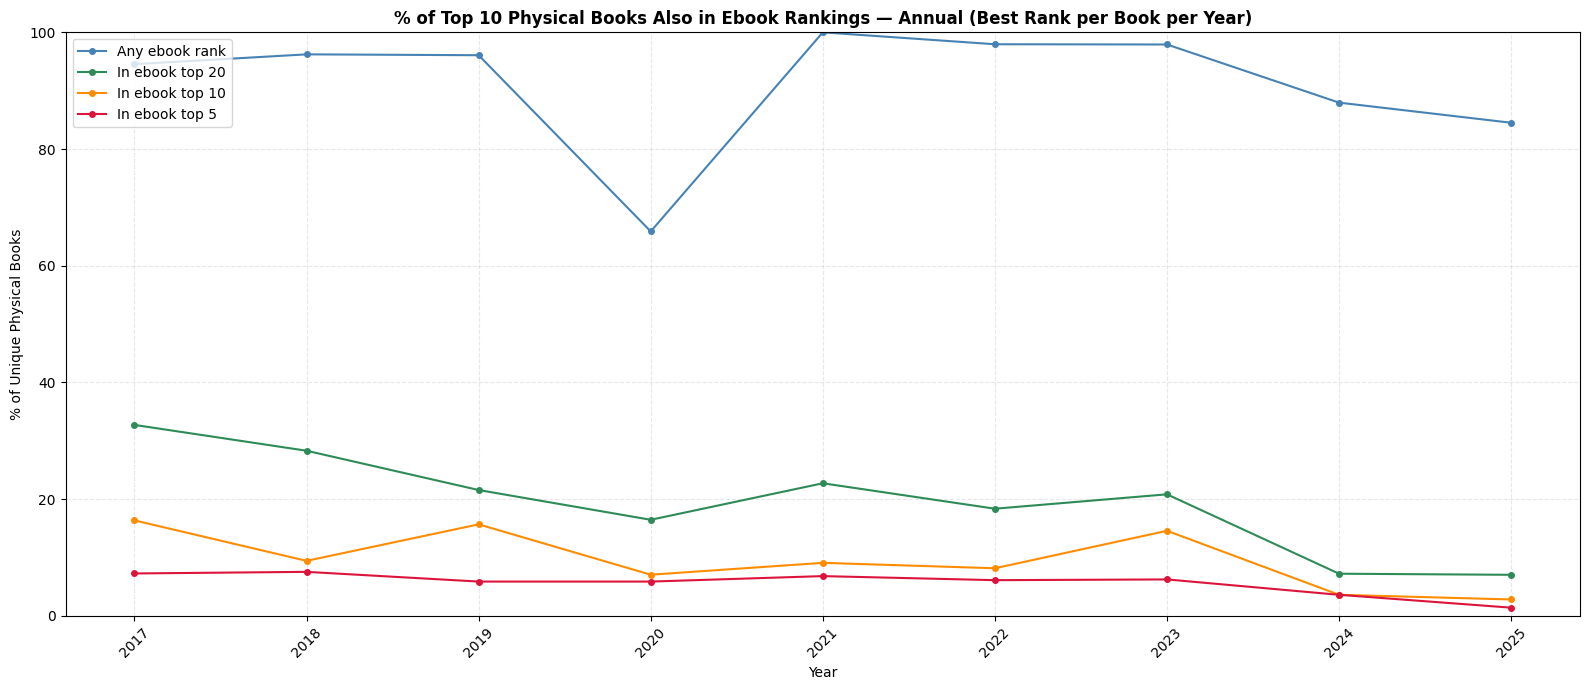

✅ Chart saved
      Unique Books  Matched  Any Match (%)  Top 5 (%)  Top 10 (%)  Top 20 (%)
Year                                                                         
2017            55       52           94.5        7.3        16.4        32.7
2018            53       51           96.2        7.5         9.4        28.3
2019            51       49           96.1        5.9        15.7        21.6
2020            85       56           65.9        5.9         7.1        16.5
2021            44       44          100.0        6.8         9.1        22.7
2022            49       48           98.0        6.1         8.2        18.4
2023            48       47           97.9        6.2        14.6        20.8
2024            83       73           88.0        3.6         3.6         7.2
2025            71       60           84.5        1.4         2.8         7.0


In [15]:
#plot % overlap between top 10 physical books -> ebooks per month to identify general trends

# take the highest ebook rank per book per year
best_rank_per_year = (
    book_to_ebook
    .groupby(['checkoutyear', 'book_title'])['ebook_rank']
    .min()
    .reset_index()
)

# aggregate to annual grain
annual_raw = best_rank_per_year.groupby('checkoutyear').agg(
    total    = ('book_title', 'count'),
    matched  = ('ebook_rank', lambda x: x.notna().sum()),
    in_top5  = ('ebook_rank', lambda x: (x <= 5).sum()),
    in_top10 = ('ebook_rank', lambda x: (x <= 10).sum()),
    in_top20 = ('ebook_rank', lambda x: (x <= 20).sum()),
).reset_index()

annual_raw['pct_matched'] = annual_raw['matched']  / annual_raw['total'] * 100
annual_raw['pct_top5']    = annual_raw['in_top5']   / annual_raw['total'] * 100
annual_raw['pct_top10']   = annual_raw['in_top10']  / annual_raw['total'] * 100
annual_raw['pct_top20']   = annual_raw['in_top20']  / annual_raw['total'] * 100

# plot
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

ax.plot(annual_raw['checkoutyear'], annual_raw['pct_matched'], label='Any ebook rank',  linewidth=1.5, marker='o', markersize=4, color='steelblue')
ax.plot(annual_raw['checkoutyear'], annual_raw['pct_top20'],   label='In ebook top 20', linewidth=1.5, marker='o', markersize=4, color='seagreen')
ax.plot(annual_raw['checkoutyear'], annual_raw['pct_top10'],   label='In ebook top 10', linewidth=1.5, marker='o', markersize=4, color='darkorange')
ax.plot(annual_raw['checkoutyear'], annual_raw['pct_top5'],    label='In ebook top 5',  linewidth=1.5, marker='o', markersize=4, color='crimson')

ax.set_title('% of Top 10 Physical Books Also in Ebook Rankings — Annual (Best Rank per Book per Year)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% of Unique Physical Books')
ax.set_xlabel('Year')
ax.set_ylim(0, 100)
ax.set_xticks(annual_raw['checkoutyear'])
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{figure_output_dir}/pct_books_in_ebook_rankings_combined.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

# tabular results
display_df = annual_raw[['checkoutyear', 'total', 'matched', 'pct_matched',
                          'pct_top5', 'pct_top10', 'pct_top20']].copy()
display_df.columns = ['Year', 'Unique Books', 'Matched', 'Any Match (%)',
                      'Top 5 (%)', 'Top 10 (%)', 'Top 20 (%)']
print(display_df.set_index('Year').round(1).to_string())

### Check borrowing trends against bestseller trends


In [16]:
## pull in monthly nyt bestseller list data - see 04_nyt_books_ingestion.ipynb for more details

nyt_data_dir = '/Users/audriswong/data-portfolio/projects/seattle-checkouts/data/external/nyt_bestsellers/processed/'
nyt_monthly = pd.read_parquet(f'{nyt_data_dir}/monthly_nyt.parquet')

nyt_monthly.head(20)

,year,month,work_key,title,author,list_name,display_name,weeks_on_list_this_month,peak_rank,avg_rank,max_consecutive_weeks,new_entry,total_weeks_on_list
0,2017,1,10-DAY GREEN SMOOTHIE CLEANSE || J. J. SMITH,10-DAY GREEN SMOOTHIE CLEANSE,J. J. SMITH,health,Health,5,6,7.80,4,True,0
1,2017,1,15TH AFFAIR || JAMES PATTERSON AND MAXINE PAETRO,15TH AFFAIR,JAMES PATTERSON AND MAXINE PAETRO,trade-fiction-paperback,Paperback Trade Fiction,1,12,12.00,1,True,0
2,2017,1,5TH WAVE || RICK YANCEY,5TH WAVE,RICK YANCEY,series-books,Children’s & Young Adult Series,1,10,10.00,1,True,15
3,2017,1,99 || WAYNE GRETZKY WITH KIRSTIE MCLELLAN DAY,99,WAYNE GRETZKY WITH KIRSTIE MCLELLAN DAY,sports,Sports and Fitness,5,11,16.40,4,True,0
4,2017,1,A COURT OF MIST AND FURY || SARAH J. MAAS,A COURT OF MIST AND FURY,SARAH J. MAAS,young-adult-e-book,Young Adult E-Book,3,4,4.33,2,False,19
5,2017,1,A DOG'S PURPOSE || W. BRUCE CAMERON,A DOG'S PURPOSE,W. BRUCE CAMERON,combined-print-and-e-book-fiction,Combined Print & E-Book Fiction,5,1,2.60,4,False,6
6,2017,1,A DOG'S PURPOSE || W. BRUCE CAMERON,A DOG'S PURPOSE,W. BRUCE CAMERON,e-book-fiction,E-Book Fiction,1,14,14.00,1,True,0
7,2017,1,A DOG'S PURPOSE || W. BRUCE CAMERON,A DOG'S PURPOSE,W. BRUCE CAMERON,mass-market-paperback,Paperback Mass-Market Fiction,5,1,3.20,4,False,6
8,2017,1,A DOG'S PURPOSE || W. BRUCE CAMERON,A DOG'S PURPOSE,W. BRUCE CAMERON,trade-fiction-paperback,Paperback Trade Fiction,5,1,1.80,4,False,23
9,2017,1,A FIELD GUIDE TO REDHEADS || ELIZABETH GRAEBER,A FIELD GUIDE TO REDHEADS,ELIZABETH GRAEBER,fashion-manners-and-customs,"Fashion, Manners and Customs",3,5,5.00,3,True,0


In [17]:
##match physical books to bestsellers

# ── Prep monthly_nyt to match expected schema ─────────────────────────────────
nyt_prepped = nyt_monthly.rename(columns={
    'year':   'checkoutyear',
    'month':  'checkoutmonth',
    'author': 'creator'
}).copy()

nyt_prepped['month_checkout_rank'] = nyt_prepped['peak_rank']
nyt_prepped['total_checkouts']     = None
nyt_prepped['month_date']          = pd.to_datetime({
    'year':  nyt_prepped['checkoutyear'],
    'month': nyt_prepped['checkoutmonth'],
    'day':   1
})

# ── book -> nyt bestseller fuzzy match
books_to_nyt = fuzzy_cross_rank(
    origin_df      = book_ranked,
    destination_df = nyt_prepped,
    origin_label   = 'book',
    destination_label = 'nyt',
    origin_rank_cutoff = 10,
    author_threshold   = 60,
    extra_destination_fields = ['list_name', 'display_name']  
)

print_match_report(books_to_nyt, 'book', 'nyt', rank_cutoff=10)
print(books_to_nyt.head())

=== Fuzzy Match: book → nyt (top 10) ===
  Total entries    : 1,080
  Matched          : 531 (49.2%)
  Not matched      : 549 (50.8%)

  nyt top  5:   281 (26.0%)
  nyt top 10:   414 (38.3%)
  nyt top 20:   531 (49.2%)
  nyt top 50:   531 (49.2%)
   checkoutyear  checkoutmonth month_date  \
0          2017              1 2017-01-01   
1          2017              1 2017-01-01   
2          2017              1 2017-01-01   
3          2017              1 2017-01-01   
4          2017              1 2017-01-01   

                                          book_title        book_author  \
0                  TODAY WILL BE DIFFERENT : A NOVEL      SEMPLE, MARIA   
1  HILLBILLY ELEGY : A MEMOIR OF A FAMILY AND CUL...       VANCE, J. D.   
2                 THE UNDERGROUND RAILROAD : A NOVEL  WHITEHEAD, COLSON   
3                                 MOONGLOW : A NOVEL    CHABON, MICHAEL   
4                THE WRONG SIDE OF GOODBYE : A NOVEL  CONNELLY, MICHAEL   

   book_rank  book_total_checko

In [18]:
##match physical books to bestsellers

# ── ebook -> nyt bestseller fuzzy match
ebooks_to_nyt = fuzzy_cross_rank(
    origin_df      = ebook_ranked,
    destination_df = nyt_prepped,
    origin_label   = 'ebook',
    destination_label = 'nyt',
    origin_rank_cutoff = 10,
    author_threshold   = 60,
    extra_destination_fields = ['list_name', 'display_name']  
)

print_match_report(ebooks_to_nyt, 'ebook', 'nyt', rank_cutoff=10)
print(ebooks_to_nyt.head())

=== Fuzzy Match: ebook → nyt (top 10) ===
  Total entries    : 1,080
  Matched          : 618 (57.2%)
  Not matched      : 462 (42.8%)

  nyt top  5:   324 (30.0%)
  nyt top 10:   483 (44.7%)
  nyt top 20:   618 (57.2%)
  nyt top 50:   618 (57.2%)
   checkoutyear  checkoutmonth month_date  \
0          2017              1 2017-01-01   
1          2017              1 2017-01-01   
2          2017              1 2017-01-01   
3          2017              1 2017-01-01   
4          2017              1 2017-01-01   

                                         ebook_title      ebook_author  \
0  THE GOLDFINCH: A NOVEL (PULITZER PRIZE FOR FIC...       DONNA TARTT   
1  THE UNDERGROUND RAILROAD (OPRAH'S BOOK CLUB): ...  COLSON WHITEHEAD   
2                            TODAY WILL BE DIFFERENT      MARIA SEMPLE   
3                                       COMMONWEALTH      ANN PATCHETT   
4                           BETWEEN THE WORLD AND ME  TA-NEHISI COATES   

   ebook_rank  ebook_total_checkouts

#### define a fuzzy cross rank function that is month agnostic to allow for lead/lag analysis

In [19]:
def general_fuzzy_cross_rank(origin_df, destination_df,
                     origin_label='origin', destination_label='destination',
                     origin_rank_cutoff=10, destination_rank_cutoff=None,
                     author_threshold=70, min_substring_len=3,
                     overlap_threshold=0.8,
                     extra_destination_fields=None,
                     month_window=0):  # ← 0 = same month only, N = ±N months
    """
    Direction-agnostic fuzzy matching function.
    Matches titles in origin_df to closest title in destination_df.
    Title matching criterion: >= overlap_threshold word overlap (shorter → longer).

    Parameters:
        origin_df                : DataFrame being iterated
        destination_df           : DataFrame being searched
        origin_label             : label for origin columns (e.g. 'book' or 'ebook')
        destination_label        : label for destination columns (e.g. 'ebook' or 'book')
        origin_rank_cutoff       : only consider origin titles ranked <= this value
        destination_rank_cutoff  : only search destination titles ranked <= this value (None = no filter)
        author_threshold         : minimum fuzzy author score to consider
        min_substring_len        : minimum word length to be considered meaningful
        overlap_threshold        : minimum word overlap fraction to accept a title match (default 0.8)
        extra_destination_fields : optional list of column names to pull from destination row
                                   e.g. ['list_name', 'display_name']. Defaults to None.
        month_window             : number of months before/after origin month to search.
                                   0 = same month only. Returns closest match by offset.
                                   month_offset in results: negative = dest before origin,
                                   positive = dest after origin.
    """

    noise = {'a', 'an', 'the', 'of', 'in', 'and', 'or', 'to', 'by', 'for',
             'novel', 'memoir', 'story', 'book', 'vol', 'volume', 'series',
             'pick', 'winner', 'prize', 'club', 'read', 'with', 'jenna',
             'oprah', 'reese', 'pulitzer', 'collection', 'continuing'}

    def clean_author(author):
        author = re.sub(r'\(.*?\)', '', str(author))
        author = re.sub(r',?\s*(JR|SR|II|III|IV)\.?', '', author, flags=re.IGNORECASE)
        author = re.sub(r',?\s*\d{4}-?(\d{4})?', '', author)
        return author.strip()

    def meaningful_words(title, author=None):
        words = set(re.sub(r'[^a-z0-9\s]', ' ', str(title).lower()).split())
        author_words = set(re.sub(r'[^a-z0-9\s]', ' ', str(author).lower()).split()) if author else set()
        return [w for w in words
                if w not in noise
                and len(w) >= min_substring_len
                and w not in author_words]

    def word_overlap(words_a, words_b):
        if not words_a or not words_b:
            return 0.0
        shorter = words_a if len(words_a) <= len(words_b) else words_b
        longer  = ' '.join(words_b if len(words_a) <= len(words_b) else words_a)
        matched = [w for w in shorter if w in longer]
        return len(matched) / len(shorter)

    def offset_month(year, month, offset):
        """Shift (year, month) by offset months, handling year boundaries."""
        total = (year * 12 + month - 1) + offset
        return total // 12, (total % 12) + 1

    results = []

    for (year, month), origin_group in (
        origin_df[origin_df['month_checkout_rank'] <= origin_rank_cutoff]
        .groupby(['checkoutyear', 'checkoutmonth'])
    ):
        for _, origin_row in origin_group.iterrows():
            origin_author_clean = clean_author(origin_row['creator'])
            origin_words        = meaningful_words(origin_row['title'], origin_row['creator'])

            best_match         = None
            best_title_score   = None
            best_author_score  = None
            best_matched_words = None
            best_overlap       = None
            best_offset        = None
            best_dest_row      = None

            # ── search offsets from 0 outward: 0, -1, +1, -2, +2, ... ────────
            offsets = sorted(range(-month_window, month_window + 1),
                             key=lambda x: (abs(x), x))  # 0 first, then closest

            for offset in offsets:
                dest_year, dest_month = offset_month(year, month, offset)

                dest_window = destination_df[
                    (destination_df['checkoutyear']  == dest_year) &
                    (destination_df['checkoutmonth'] == dest_month)
                ]
                if destination_rank_cutoff is not None:
                    dest_window = dest_window[dest_window['month_checkout_rank'] <= destination_rank_cutoff]
                if dest_window.empty:
                    continue

                dest_window  = dest_window.drop_duplicates('title').copy()
                dest_authors = dest_window['creator'].tolist()

                # Step 1 — fuzzy author match
                author_candidates = process.extract(origin_author_clean, dest_authors,
                                                    scorer=fuzz.token_sort_ratio, limit=10)
                passing_authors = [(score, idx) for _, score, idx in author_candidates
                                   if score >= author_threshold]
                if not passing_authors:
                    continue

                # Step 2 — title overlap among passing authors
                title_candidates = []
                for author_score, idx in passing_authors:
                    candidate     = dest_window.iloc[idx]
                    dest_words    = meaningful_words(candidate['title'])
                    overlap       = word_overlap(origin_words, dest_words)
                    matched_words = [w for w in (origin_words if len(origin_words) <= len(dest_words)
                                                 else dest_words)
                                     if w in ' '.join(dest_words if len(origin_words) <= len(dest_words)
                                                      else origin_words)]
                    if overlap >= overlap_threshold:
                        title_score = fuzz.WRatio(origin_row['title'], candidate['title'])
                        title_candidates.append((title_score, author_score,
                                                 overlap, idx, matched_words))

                if title_candidates:
                    title_candidates.sort(key=lambda x: x[0], reverse=True)
                    best_title_score, best_author_score, best_overlap, idx, best_matched_words = title_candidates[0]
                    best_match    = dest_window.iloc[idx]
                    best_offset   = offset
                    break  # stop at closest offset that yields a match

            # ── build result row ──────────────────────────────────────────────
            if best_match is not None:
                row = {
                    'checkoutyear':                         year,
                    'checkoutmonth':                        month,
                    'month_date':                           origin_row.get('month_date'),
                    f'{origin_label}_title':                origin_row['title'],
                    f'{origin_label}_author':               origin_row['creator'],
                    f'{origin_label}_rank':                 origin_row['month_checkout_rank'],
                    f'{origin_label}_total_checkouts':      origin_row.get('total_checkouts'),
                    f'{destination_label}_title':           best_match['title'],
                    f'{destination_label}_author':          best_match['creator'],
                    f'{destination_label}_rank':            best_match['month_checkout_rank'],
                    f'{destination_label}_total_checkouts': best_match.get('total_checkouts'),
                    'month_offset':                         best_offset,
                    'title_score':                          best_title_score,
                    'author_score':                         best_author_score,
                    'word_overlap':                         best_overlap,
                    'matched_words':                        str(best_matched_words),
                    'genre':                                origin_row.get('genre'),
                    'match_found':                          True,
                }
                if extra_destination_fields:
                    for field in extra_destination_fields:
                        row[f'{destination_label}_{field}'] = best_match.get(field)

            else:
                row = {
                    'checkoutyear':                         year,
                    'checkoutmonth':                        month,
                    'month_date':                           origin_row.get('month_date'),
                    f'{origin_label}_title':                origin_row['title'],
                    f'{origin_label}_author':               origin_row['creator'],
                    f'{origin_label}_rank':                 origin_row['month_checkout_rank'],
                    f'{origin_label}_total_checkouts':      origin_row.get('total_checkouts'),
                    f'{destination_label}_title':           None,
                    f'{destination_label}_author':          None,
                    f'{destination_label}_rank':            None,
                    f'{destination_label}_total_checkouts': None,
                    'month_offset':                         None,
                    'title_score':                          None,
                    'author_score':                         None,
                    'word_overlap':                         None,
                    'matched_words':                        None,
                    'genre':                                origin_row.get('genre'),
                    'match_found':                          False,
                }
                if extra_destination_fields:
                    for field in extra_destination_fields:
                        row[f'{destination_label}_{field}'] = None

            results.append(row)

    return pd.DataFrame(results)

#### analyze popularity across physical book, ebook, and bestseller lists across time

In [20]:
# prep nyt as before
nyt_prepped = nyt_monthly.rename(columns={
    'year':   'checkoutyear',
    'month':  'checkoutmonth',
    'author': 'creator'
}).copy()
nyt_prepped['month_checkout_rank'] = nyt_prepped['peak_rank']
nyt_prepped['total_checkouts']     = None
nyt_prepped['month_date']          = pd.to_datetime({
    'year':  nyt_prepped['checkoutyear'],
    'month': nyt_prepped['checkoutmonth'],
    'day':   1
})

#return book/ ebook with highest title match score

#books and ebooks are top 10 monthly checkouts ONLY

# books → nyt: find which book titles exist on NYT list within 12 months of the checkout month
books_to_nyt_wide = general_fuzzy_cross_rank(
    origin_df                = book_ranked,
    destination_df           = nyt_prepped,
    origin_label             = 'book',
    destination_label        = 'nyt',
    origin_rank_cutoff       = 10,   
    author_threshold         = 60,
    overlap_threshold        = 0.8,
    month_window             = 12,    # search across 12 months
    extra_destination_fields = ['list_name', 'display_name']
)

# ebooks → nyt
ebooks_to_nyt_wide = general_fuzzy_cross_rank(
    origin_df                = ebook_ranked,
    destination_df           = nyt_prepped,
    origin_label             = 'ebook',
    destination_label        = 'nyt',
    origin_rank_cutoff       = 10,
    author_threshold         = 60,
    overlap_threshold        = 0.8,
    month_window             = 12,    # search across 12 months,
    extra_destination_fields = ['list_name', 'display_name']
)

# books → ebooks 
books_to_ebooks_wide = general_fuzzy_cross_rank(
    origin_df          = book_ranked,
    destination_df     = ebook_ranked,
    origin_label       = 'book',
    destination_label  = 'ebook',
    origin_rank_cutoff = 10,
    author_threshold   = 70,
    overlap_threshold  = 0.8,
    month_window       = 12, # search across 12 months,
)

In [21]:
##create three way crosswalk table

# one title might be in multiple NYT lists.  priority rank lists, and return list with highest priority
list_priority = {
    'combined-print-and-e-book-fiction':      1,
    'combined-print-and-e-book-nonfiction':   2,
    'hardcover-fiction':                      3,
    'hardcover-nonfiction':                   4,
    'trade-fiction-paperback':                5,
    'advice-how-to-and-miscellaneous':        6,
    'young-adult-hardcover':                  7,
    'childrens-middle-grade-hardcover':       8,
    'graphic-books-and-manga':                9,
    'series-books':                          10,
    'picture-books':                         11,
    'business-books':                        12,
    'audio-fiction':                         13,
    'audio-nonfiction':                      14,
}

nyt_prepped['list_priority'] = nyt_prepped['list_name'].map(list_priority).fillna(99)

# ── build pair tables ─────────────────────────────────────────────────────────
book_nyt_pairs = (books_to_nyt_wide[books_to_nyt_wide['match_found']]
                  [['book_title', 'book_author', 'nyt_title',
                    'nyt_list_name', 'nyt_display_name',
                    'title_score', 'word_overlap']]
                  .merge(nyt_prepped[['title', 'list_priority']].drop_duplicates('title'),
                         left_on='nyt_title', right_on='title', how='left')
                  .sort_values('list_priority')
                  .drop_duplicates('book_title')
                  .drop(columns='title')
                  .rename(columns={'title_score':    'book_nyt_score',
                                   'word_overlap':   'book_nyt_overlap',
                                   'list_priority':  'book_nyt_list_priority'}))

ebook_nyt_pairs = (ebooks_to_nyt_wide[ebooks_to_nyt_wide['match_found']]
                   [['ebook_title', 'nyt_title',
                     'nyt_list_name', 'nyt_display_name',
                     'title_score', 'word_overlap']]
                   .merge(nyt_prepped[['title', 'list_priority']].drop_duplicates('title'),
                          left_on='nyt_title', right_on='title', how='left')
                   .sort_values('list_priority')
                   .drop_duplicates('ebook_title')
                   .drop(columns='title')
                   .rename(columns={'title_score':    'ebook_nyt_score',
                                    'word_overlap':   'ebook_nyt_overlap',
                                    'nyt_title':      'nyt_title_from_ebook',
                                    'nyt_list_name':  'nyt_list_name_from_ebook',
                                    'nyt_display_name': 'nyt_display_name_from_ebook',
                                    'list_priority':  'ebook_nyt_list_priority'}))

book_ebook_pairs = (books_to_ebooks_wide[books_to_ebooks_wide['match_found']]
                    [['book_title', 'ebook_title', 'title_score', 'word_overlap']]
                    .drop_duplicates('book_title')
                    .rename(columns={'title_score':  'book_ebook_score',
                                     'word_overlap': 'book_ebook_overlap'}))

# ── derive universe of titles from pair tables (already top 10 filtered) ──────
all_books  = pd.DataFrame({'book_title': pd.concat([
                               book_nyt_pairs['book_title'],
                               book_ebook_pairs['book_title']
                           ]).dropna().unique()})

all_ebooks = pd.DataFrame({'ebook_title': pd.concat([
                               book_ebook_pairs['ebook_title'],
                               ebook_nyt_pairs['ebook_title']
                           ]).dropna().unique()})

all_nyt    = pd.DataFrame({'nyt_title': pd.concat([
                               book_nyt_pairs['nyt_title'],
                               ebook_nyt_pairs['nyt_title_from_ebook']
                           ]).dropna().unique()})

# ── build crosswalk ───────────────────────────────────────────────────────────
crosswalk = (all_books
             # attach nyt match via book path
             .merge(book_nyt_pairs, on='book_title', how='left')
             # attach ebook match via book path
             .merge(book_ebook_pairs, on='book_title', how='left')
             # attach nyt match via ebook path (fills gaps where book→nyt failed)
             .merge(ebook_nyt_pairs, on='ebook_title', how='left')
             # fill nyt_title gaps using ebook→nyt path
             .assign(
                 nyt_title       = lambda d: d['nyt_title'].fillna(d['nyt_title_from_ebook']),
                 nyt_list_name   = lambda d: d['nyt_list_name'].fillna(d['nyt_list_name_from_ebook']),
                 nyt_display_name= lambda d: d['nyt_display_name'].fillna(d['nyt_display_name_from_ebook']),
             )
             .drop(columns=['nyt_title_from_ebook', 'nyt_list_name_from_ebook',
                            'nyt_display_name_from_ebook', 'ebook_nyt_score',
                            'ebook_nyt_overlap', 'ebook_nyt_list_priority'])
)

# ── add ebook-only rows (ebooks with no book match) ───────────────────────────
ebook_only = (all_ebooks[~all_ebooks['ebook_title'].isin(crosswalk['ebook_title'].dropna())]
              .merge(ebook_nyt_pairs[['ebook_title', 'nyt_title_from_ebook',
                                      'nyt_list_name_from_ebook',
                                      'nyt_display_name_from_ebook']]
                     .rename(columns={'nyt_title_from_ebook':       'nyt_title',
                                      'nyt_list_name_from_ebook':   'nyt_list_name',
                                      'nyt_display_name_from_ebook':'nyt_display_name'}),
                     on='ebook_title', how='left'))

# ── add nyt-only rows (nyt titles with no book or ebook match) ────────────────
matched_nyt = set(crosswalk['nyt_title'].dropna()) | set(ebook_only['nyt_title'].dropna())
nyt_only    = all_nyt[~all_nyt['nyt_title'].isin(matched_nyt)].copy()

# ── union all three ───────────────────────────────────────────────────────────
crosswalk_full = (pd.concat([crosswalk, ebook_only, nyt_only], ignore_index=True)
                  .reset_index(drop=True))

# ── coverage summary ──────────────────────────────────────────────────────────
has_book  = crosswalk_full['book_title'].notna()
has_ebook = crosswalk_full['ebook_title'].notna()
has_nyt   = crosswalk_full['nyt_title'].notna()

print(f"Total rows         : {len(crosswalk_full):>6,}")
print(f"All three sources  : {(has_book & has_ebook & has_nyt).sum():>6,}")
print(f"Book + NYT only    : {(has_book & has_nyt & ~has_ebook).sum():>6,}")
print(f"Book + ebook only  : {(has_book & has_ebook & ~has_nyt).sum():>6,}")
print(f"Ebook + NYT only   : {(has_ebook & has_nyt & ~has_book).sum():>6,}")
print(f"Book only          : {(has_book & ~has_ebook & ~has_nyt).sum():>6,}")
print(f"Ebook only         : {(has_ebook & ~has_book & ~has_nyt).sum():>6,}")
print(f"NYT only           : {(has_nyt & ~has_book & ~has_ebook).sum():>6,}")
print(f"\nColumns: {crosswalk_full.columns.tolist()}")

Total rows         :    501
All three sources  :    272
Book + NYT only    :      1
Book + ebook only  :    158
Ebook + NYT only   :     70
Book only          :      0
Ebook only         :      0
NYT only           :      0

Columns: ['book_title', 'book_author', 'nyt_title', 'nyt_list_name', 'nyt_display_name', 'book_nyt_score', 'book_nyt_overlap', 'book_nyt_list_priority', 'ebook_title', 'book_ebook_score', 'book_ebook_overlap']


In [22]:
## how many months do titles stay in each list, by first appearance location?
def peak_month(series, year_col, month_col, rank_col):
    """Return the (year, month) when rank was lowest (best)."""
    if series.empty:
        return None, None
    best = series.loc[series[rank_col].idxmin()]
    return int(best[year_col]), int(best[month_col])
    
def months_between(year1, month1, year2, month2):
    """Signed difference in months. Positive = year2/month2 is later."""
    return (year2 * 12 + month2) - (year1 * 12 + month1)

def classify_leader(row):
    appearances = {
        'nyt':   (row['nyt_first_yr'],   row['nyt_first_mo']),
        'book':  (row['book_first_yr'],  row['book_first_mo']),
        'ebook': (row['ebook_first_yr'], row['ebook_first_mo']),
    }
    # drop sources where either value is None OR NaN
    valid = {
        k: v for k, v in appearances.items()
        if v[0] is not None and v[1] is not None
        and pd.notna(v[0]) and pd.notna(v[1])
    }
    if not valid:
        return 'unknown'

    min_val = min(valid[k][0] * 12 + valid[k][1] for k in valid)
    leaders = [k for k in valid if valid[k][0] * 12 + valid[k][1] == min_val]

    if len(leaders) == 1:
        return f'first_{leaders[0]}'
    else:
        return 'tie_' + '_'.join(sorted(leaders))

def get_title_series(df, title, title_col, year_col, month_col, rank_col,
                     checkouts_col=None, rank_cutoff=None):
    """Pull full monthly time series for a single title."""
    subset = df[df[title_col] == title].copy()
    if rank_cutoff is not None:
        subset = subset[subset[rank_col] <= rank_cutoff]
    cols = [year_col, month_col, rank_col]
    if checkouts_col and checkouts_col in df.columns:
        cols.append(checkouts_col)
    return subset[cols].sort_values([year_col, month_col]).reset_index(drop=True)

def count_appearances(series, year_col, month_col):
    """Count distinct months a title appears in a source."""
    if series.empty:
        return 0
    return series[[year_col, month_col]].drop_duplicates().shape[0]

def first_appearance(series, year_col, month_col):
    """Return the (year, month) of the earliest appearance on any list."""
    if series.empty:
        return None, None
    earliest = series.sort_values([year_col, month_col]).iloc[0]
    return int(earliest[year_col]), int(earliest[month_col])

def build_title_timeline(crosswalk_row, book_ranked, ebook_ranked, nyt_prepped,
                         book_rank_cutoff=10, ebook_rank_cutoff=10, nyt_rank_cutoff=10):

    book_title  = crosswalk_row['book_title']
    ebook_title = crosswalk_row['ebook_title']
    nyt_title   = crosswalk_row['nyt_title']

    # single series per source with rank cutoff applied to everything
    book_series  = get_title_series(book_ranked,  book_title,  'title', 'checkoutyear', 'checkoutmonth', 'month_checkout_rank', 'total_checkouts', rank_cutoff=book_rank_cutoff)  if pd.notna(book_title)  else pd.DataFrame()
    ebook_series = get_title_series(ebook_ranked, ebook_title, 'title', 'checkoutyear', 'checkoutmonth', 'month_checkout_rank', 'total_checkouts', rank_cutoff=ebook_rank_cutoff) if pd.notna(ebook_title) else pd.DataFrame()
    nyt_series   = get_title_series(nyt_prepped,  nyt_title,   'title', 'checkoutyear', 'checkoutmonth', 'month_checkout_rank',                    rank_cutoff=nyt_rank_cutoff)   if pd.notna(nyt_title)   else pd.DataFrame()

    # first appearance in top N
    book_yr,  book_mo  = first_appearance(book_series,  'checkoutyear', 'checkoutmonth')
    ebook_yr, ebook_mo = first_appearance(ebook_series, 'checkoutyear', 'checkoutmonth')
    nyt_yr,   nyt_mo   = first_appearance(nyt_series,   'checkoutyear', 'checkoutmonth')

    # peak rank within top N
    book_peak_rank  = int(book_series['month_checkout_rank'].min())  if not book_series.empty  else None
    ebook_peak_rank = int(ebook_series['month_checkout_rank'].min()) if not ebook_series.empty else None
    nyt_peak_rank   = int(nyt_series['month_checkout_rank'].min())   if not nyt_series.empty   else None

    # longevity = months in top N
    book_months  = count_appearances(book_series,  'checkoutyear', 'checkoutmonth')
    ebook_months = count_appearances(ebook_series, 'checkoutyear', 'checkoutmonth')
    nyt_months   = count_appearances(nyt_series,   'checkoutyear', 'checkoutmonth')

    # offsets between first appearances
    nyt_to_book   = months_between(nyt_yr,  nyt_mo,  book_yr,  book_mo)  if all([nyt_yr,  book_yr])  else None
    nyt_to_ebook  = months_between(nyt_yr,  nyt_mo,  ebook_yr, ebook_mo) if all([nyt_yr,  ebook_yr]) else None
    book_to_ebook = months_between(book_yr, book_mo, ebook_yr, ebook_mo) if all([book_yr, ebook_yr]) else None

    return {
        'book_title':         book_title,
        'ebook_title':        ebook_title,
        'nyt_title':          nyt_title,
        'book_first_yr':      book_yr,
        'book_first_mo':      book_mo,
        'ebook_first_yr':     ebook_yr,
        'ebook_first_mo':     ebook_mo,
        'nyt_first_yr':       nyt_yr,
        'nyt_first_mo':       nyt_mo,
        'book_peak_rank':     book_peak_rank,
        'ebook_peak_rank':    ebook_peak_rank,
        'nyt_peak_rank':      nyt_peak_rank,
        'book_months':        book_months,
        'ebook_months':       ebook_months,
        'nyt_months':         nyt_months,
        'nyt_to_book_mo':     nyt_to_book,
        'nyt_to_ebook_mo':    nyt_to_ebook,
        'book_to_ebook_mo':   book_to_ebook,
    }

# re-run timelines — set rank cutoffs as needed
# None = count all months regardless of rank
# e.g. book_rank_cutoff=50 = only count months title ranked in top 50 books
timeline_rows = [
    build_title_timeline(row, book_ranked, ebook_ranked, nyt_prepped,
                         # only consider titles in top 10 monthly checkouts (books/ ebooks) and top 10 per nyt list
                         book_rank_cutoff=10,
                         ebook_rank_cutoff=10,
                         nyt_rank_cutoff=10)
    for _, row in crosswalk_full.iterrows()
]

title_timelines = pd.DataFrame(timeline_rows)
title_timelines['first_to_appear'] = title_timelines.apply(classify_leader, axis=1)

In [23]:
crosstab = (title_timelines
            .groupby('first_to_appear')
            .agg(
                n_titles      = ('book_title',  'size'),
                n_book_titles = ('book_title',  lambda x: x.notna().sum()),
                n_ebook_titles= ('ebook_title', lambda x: x.notna().sum()),
                n_nyt_titles  = ('nyt_title',   lambda x: x.notna().sum()),
            )
            .reset_index()
            .sort_values('n_titles', ascending=False))

print(crosstab.to_string(index=False))

   first_to_appear  n_titles  n_book_titles  n_ebook_titles  n_nyt_titles
        first_book       191            191             191            35
         first_nyt       153             98             153           153
      tie_book_nyt       130            130             129           130
     tie_ebook_nyt        11              0              11            11
tie_book_ebook_nyt         8              8               8             8
       first_ebook         5              1               5             5
    tie_book_ebook         3              3               3             1


#### How does the overlap between popular SPL titles and Bestseller list titles trend over time?  where does popularity originate from?
##### SPL popular titles are increasingly unique from NYT list over time, starting in 2024, at the expense of titles that simultaneously debut in popular SPL lists and NYT, suggesting Seattle readers are growing increasingly unique from national tastes.¶

      segment  n_titles  n_book_titles  n_ebook_titles  n_nyt_titles  avg_book_months  avg_ebook_months  avg_nyt_months  pct_of_total
     spl_only       176            175             176            18             1.61              0.22            0.00          35.1
spl_leads_nyt        23             20              23            23             2.70              4.00            4.74           4.6
 simultaneous       149            138             148           149             2.93              2.21            5.17          29.7
nyt_leads_spl       153             98             153           153             1.67              3.46           13.12          30.5


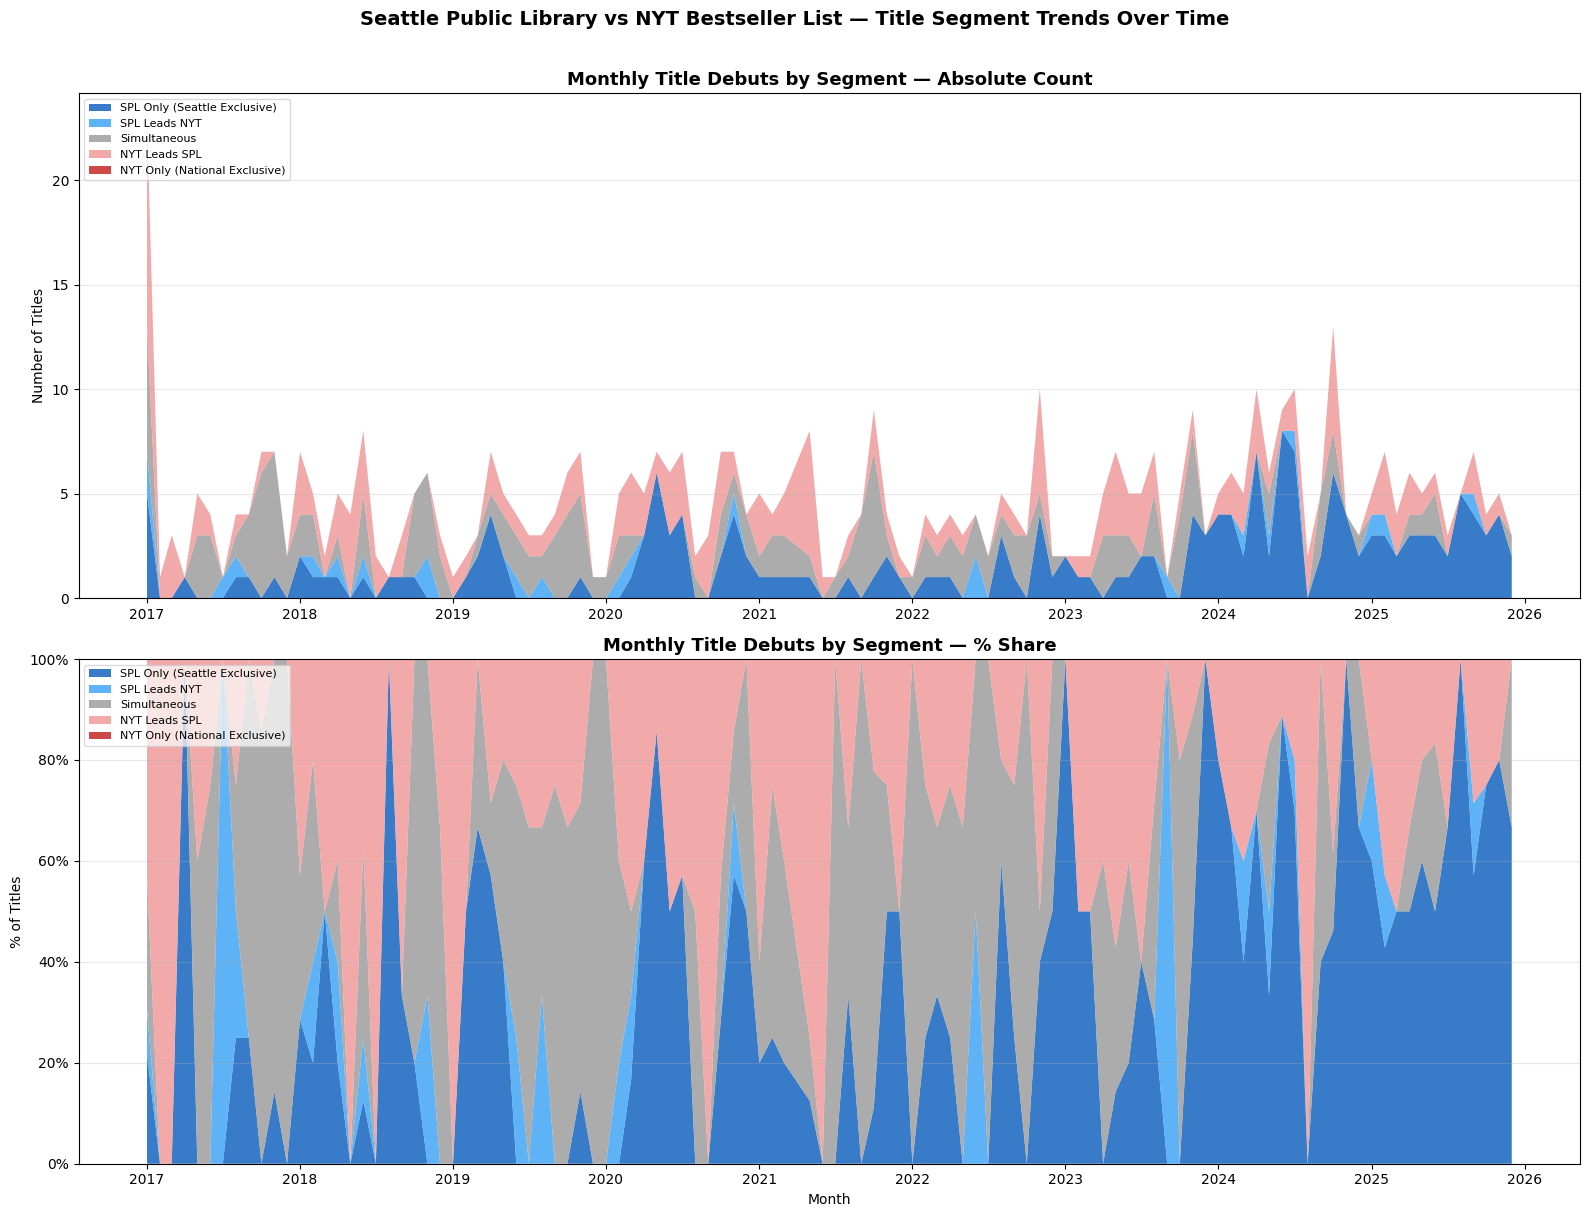

✅ Chart saved to outputs/figures/


In [24]:
# segment cleanly 
def segment_title(row):
    has_book  = pd.notna(row['book_first_yr'])  or pd.notna(row['ebook_first_yr'])
    has_nyt   = pd.notna(row['nyt_first_yr'])
    has_spl   = has_book  # SPL = either book or ebook

    # no data at all
    if not has_spl and not has_nyt:
        return 'unknown'

    # only in one ecosystem
    if has_spl and not has_nyt:
        return 'spl_only'        # Seattle exclusive
    if has_nyt and not has_spl:
        return 'nyt_only'        # National exclusive

    # appears in both — determine timing
    # use earliest SPL appearance across book and ebook
    spl_dates = []
    if pd.notna(row['book_first_yr'])  and pd.notna(row['book_first_mo']):
        spl_dates.append(row['book_first_yr'] * 12 + row['book_first_mo'])
    if pd.notna(row['ebook_first_yr']) and pd.notna(row['ebook_first_mo']):
        spl_dates.append(row['ebook_first_yr'] * 12 + row['ebook_first_mo'])

    nyt_date  = row['nyt_first_yr'] * 12 + row['nyt_first_mo']
    spl_date  = min(spl_dates)

    if spl_date < nyt_date:
        return 'spl_leads_nyt'   # Seattle ahead of national
    elif spl_date == nyt_date:
        return 'simultaneous'    # aligned
    else:
        return 'nyt_leads_spl'   # national ahead of Seattle

title_timelines['segment'] = title_timelines.apply(segment_title, axis=1)

# ── summary ───────────────────────────────────────────────────────────────────
segment_summary = (title_timelines
                   .groupby('segment')
                   .agg(
                       n_titles       = ('segment',     'size'),
                       n_book_titles  = ('book_title',  lambda x: x.notna().sum()),
                       n_ebook_titles = ('ebook_title', lambda x: x.notna().sum()),
                       n_nyt_titles   = ('nyt_title',   lambda x: x.notna().sum()),
                       avg_book_months  = ('book_months',  'mean'),
                       avg_ebook_months = ('ebook_months', 'mean'),
                       avg_nyt_months   = ('nyt_months',   'mean'),
                   )
                   .round(2)
                   .reset_index())

# add % of total
segment_summary['pct_of_total'] = (segment_summary['n_titles'] /
                                    segment_summary['n_titles'].sum() * 100).round(1)

# define sort order
order = ['spl_only', 'spl_leads_nyt', 'simultaneous', 'nyt_leads_spl', 'nyt_only', 'unknown']
segment_summary['sort'] = segment_summary['segment'].map({v: i for i, v in enumerate(order)})
segment_summary = segment_summary.sort_values('sort').drop(columns='sort')

print(segment_summary.to_string(index=False))

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── build monthly segment counts ──────────────────────────────────────────────
# get earliest SPL date per title (min of book and ebook first appearance)
def get_spl_first_date(row):
    dates = []
    if pd.notna(row['book_first_yr'])  and pd.notna(row['book_first_mo']):
        dates.append((int(row['book_first_yr']),  int(row['book_first_mo'])))
    if pd.notna(row['ebook_first_yr']) and pd.notna(row['ebook_first_mo']):
        dates.append((int(row['ebook_first_yr']), int(row['ebook_first_mo'])))
    if not dates:
        return None, None
    earliest = min(dates, key=lambda x: x[0] * 12 + x[1])
    return earliest

def get_nyt_first_date(row):
    if pd.notna(row['nyt_first_yr']) and pd.notna(row['nyt_first_mo']):
        return int(row['nyt_first_yr']), int(row['nyt_first_mo'])
    return None, None

# assign reference month per title per segment
# for spl_only / spl_leads_nyt / simultaneous → use SPL first date
# for nyt_leads_spl → use NYT first date  
# for nyt_only → use NYT first date
def get_reference_date(row):
    seg = row['segment']
    spl_yr, spl_mo = get_spl_first_date(row)
    nyt_yr, nyt_mo = get_nyt_first_date(row)

    if seg in ('spl_only', 'spl_leads_nyt', 'simultaneous'):
        return spl_yr, spl_mo
    elif seg in ('nyt_leads_spl', 'nyt_only'):
        return nyt_yr, nyt_mo
    return None, None

title_timelines[['ref_yr', 'ref_mo']] = title_timelines.apply(
    get_reference_date, axis=1, result_type='expand'
)

title_timelines['ref_date'] = pd.to_datetime({
    'year':  title_timelines['ref_yr'],
    'month': title_timelines['ref_mo'],
    'day':   1
}, errors='coerce')

# ── monthly segment counts ────────────────────────────────────────────────────
monthly_segments = (title_timelines[title_timelines['ref_date'].notna()]
                    .groupby(['ref_date', 'segment'])
                    .size()
                    .reset_index(name='n_titles'))

# pivot to wide
monthly_pivot = (monthly_segments
                 .pivot(index='ref_date', columns='segment', values='n_titles')
                 .fillna(0))

# ensure all segments present
for seg in ['spl_only', 'spl_leads_nyt', 'simultaneous', 'nyt_leads_spl', 'nyt_only']:
    if seg not in monthly_pivot.columns:
        monthly_pivot[seg] = 0

monthly_pivot = monthly_pivot[['spl_only', 'spl_leads_nyt', 'simultaneous',
                                'nyt_leads_spl', 'nyt_only']]

# ── plot: absolute counts ─────────────────────────────────────────────────────
segment_colors = {
    'spl_only':      '#1565C0',   # dark blue  — Seattle exclusive
    'spl_leads_nyt': '#42A5F5',   # light blue — Seattle leads
    'simultaneous':  '#9E9E9E',   # grey       — aligned
    'nyt_leads_spl': '#EF9A9A',   # light red  — NYT leads
    'nyt_only':      '#C62828',   # dark red   — NYT exclusive
}

segment_labels = {
    'spl_only':      'SPL Only (Seattle Exclusive)',
    'spl_leads_nyt': 'SPL Leads NYT',
    'simultaneous':  'Simultaneous',
    'nyt_leads_spl': 'NYT Leads SPL',
    'nyt_only':      'NYT Only (National Exclusive)',
}

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── plot 1: stacked area — absolute counts ────────────────────────────────────
ax1 = axes[0]
ax1.stackplot(monthly_pivot.index,
              [monthly_pivot[seg] for seg in monthly_pivot.columns],
              labels=[segment_labels[seg] for seg in monthly_pivot.columns],
              colors=[segment_colors[seg] for seg in monthly_pivot.columns],
              alpha=0.85)

ax1.set_title('Monthly Title Debuts by Segment — Absolute Count',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Titles', fontsize=10)
ax1.set_xlabel('')
ax1.legend(loc='upper left', fontsize=8, framealpha=0.7)
ax1.grid(axis='y', alpha=0.3)

# ── plot 2: stacked area — % share ───────────────────────────────────────────
ax2 = axes[1]
monthly_pct = monthly_pivot.div(monthly_pivot.sum(axis=1), axis=0) * 100

ax2.stackplot(monthly_pct.index,
              [monthly_pct[seg] for seg in monthly_pct.columns],
              labels=[segment_labels[seg] for seg in monthly_pct.columns],
              colors=[segment_colors[seg] for seg in monthly_pct.columns],
              alpha=0.85)

ax2.set_title('Monthly Title Debuts by Segment — % Share',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('% of Titles', fontsize=10)
ax2.set_xlabel('Month', fontsize=10)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(loc='upper left', fontsize=8, framealpha=0.7)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 100)

fig.suptitle('Seattle Public Library vs NYT Bestseller List — Title Segment Trends Over Time',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{figure_output_dir}/cross_list_segment_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/figures/")

#### Do popular ebooks or popular books have more overlap with NYTimes bestseller list?
##### consistently over time, popular ebooks have more overlap with NYTimes bestseller list than physical books.

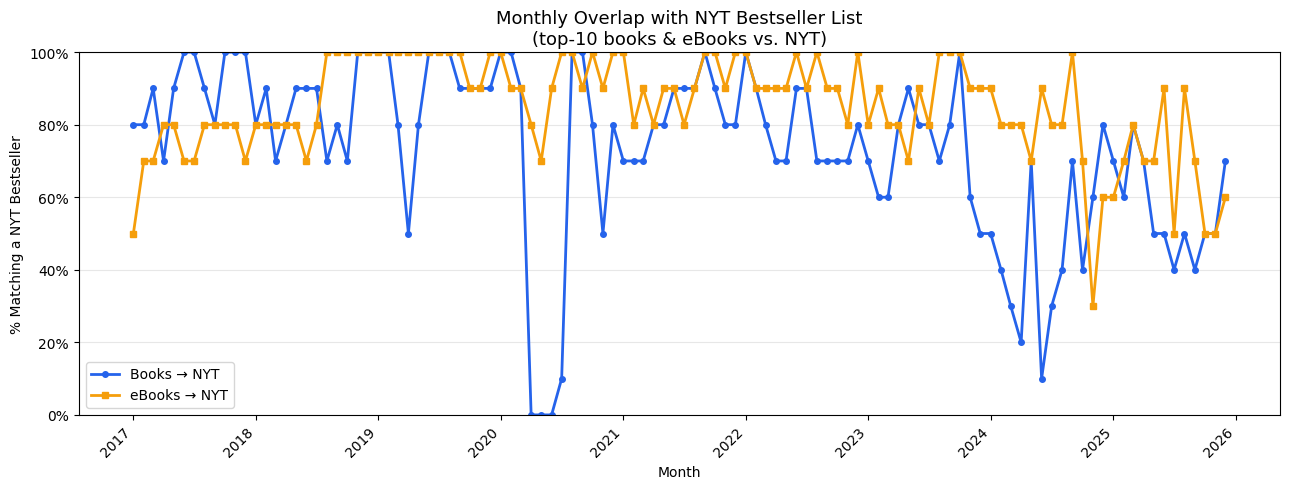

In [25]:


# ── how do top 10 monthly ebooks and books overlap with top 10 NYT? ──────────────────
# books → NYT overlap by month
book_nyt_monthly = (
    books_to_nyt_wide                          # full wide table (all books, matched or not)
    .groupby('month_date')
    .agg(
        total   = ('book_title',  'nunique'),
        matched = ('match_found', 'sum')
    )
    .assign(pct = lambda d: d['matched'] / d['total'] * 100)
    .reset_index()
)

# ebooks → NYT overlap by month
ebook_nyt_monthly = (
    ebooks_to_nyt_wide
    .groupby('month_date')
    .agg(
        total   = ('ebook_title', 'nunique'),
        matched = ('match_found', 'sum')
    )
    .assign(pct = lambda d: d['matched'] / d['total'] * 100)
    .reset_index()
)

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(book_nyt_monthly['month_date'],  book_nyt_monthly['pct'],
        marker='o', linewidth=2, markersize=4,
        color='#2563EB', label='Books → NYT')

ax.plot(ebook_nyt_monthly['month_date'], ebook_nyt_monthly['pct'],
        marker='s', linewidth=2, markersize=4,
        color='#F59E0B', label='eBooks → NYT')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(0, 100)
ax.set_xlabel('Month')
ax.set_ylabel('% Matching a NYT Bestseller')
ax.set_title('Monthly Overlap with NYT Bestseller List\n(top-10 books & eBooks vs. NYT)', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

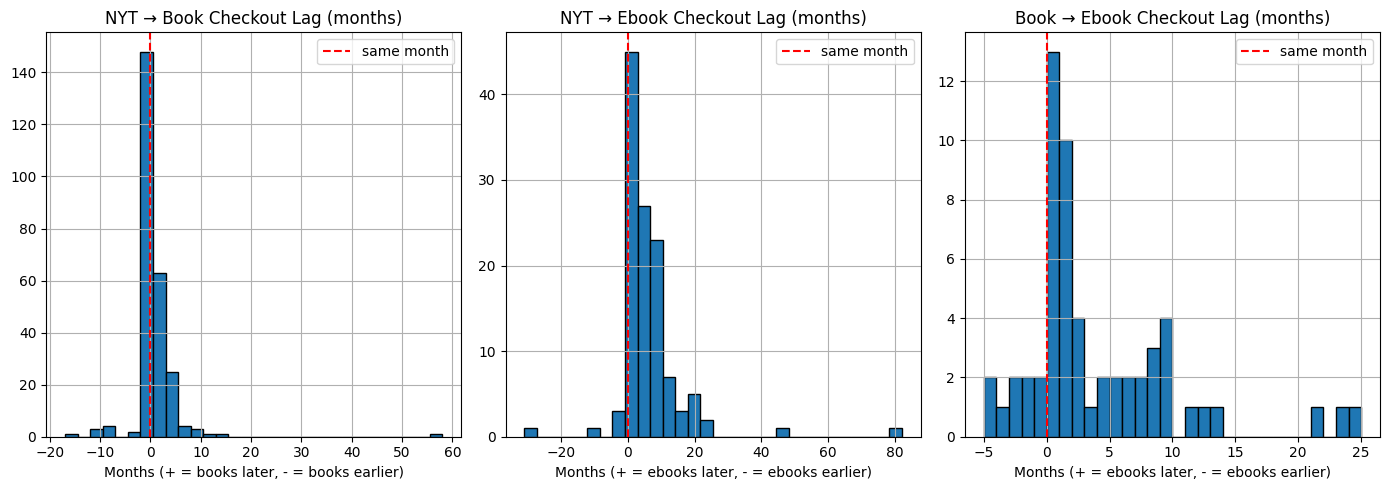

First Appearance on NYT Bestseller List -> First Appearance on Top Book Checkouts (in months)
nyt_to_book_bucket
<-6mo         8
-6 to -3      2
-3 to -1     10
-1 to 0     138
0            48
0 to 1       28
1 to 3       13
3 to 6        8
Name: count, dtype: int64

First Appearance on NYT Bestseller List -> First Appearance on Top EBook Checkouts (in months)
nyt_to_ebook_bucket
<-6mo        1
-6 to -3     1
-3 to -1     2
-1 to 0     20
0           14
0 to 1      20
1 to 3      18
3 to 6      39
Name: count, dtype: int64

First Appearance on Top Book Checkouts -> First Appearance on Top EBook Checkouts (in months)
book_to_ebook_bucket
<-6mo        0
-6 to -3     5
-3 to -1     4
-1 to 0     13
0           10
0 to 1       5
1 to 3       6
3 to 6      14
Name: count, dtype: int64


In [26]:
# look at the full distribution rather than just mean/median
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

title_timelines['nyt_to_book_mo'].hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', label='same month')
axes[0].set_title('NYT → Book Checkout Lag (months)')
axes[0].set_xlabel('Months (+ = books later, - = books earlier)')
axes[0].legend()

title_timelines['nyt_to_ebook_mo'].hist(bins=30, ax=axes[1], edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', label='same month')
axes[1].set_title('NYT → Ebook Checkout Lag (months)')
axes[1].set_xlabel('Months (+ = ebooks later, - = ebooks earlier)')
axes[1].legend()

title_timelines['book_to_ebook_mo'].hist(bins=30, ax=axes[2], edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--', label='same month')
axes[2].set_title('Book → Ebook Checkout Lag (months)')
axes[2].set_xlabel('Months (+ = ebooks later, - = ebooks earlier)')
axes[2].legend()


plt.tight_layout()
plt.show()

# also quantify how many titles fall in each bucket
bins = [-24, -6, -3, -1, 0, 1, 3, 6, 24]
labels = ['<-6mo', '-6 to -3', '-3 to -1', '-1 to 0', '0', '0 to 1', '1 to 3', '3 to 6']

title_timelines['nyt_to_book_bucket'] = pd.cut(
    title_timelines['nyt_to_book_mo'], bins=bins, labels=labels
)

title_timelines['nyt_to_ebook_bucket'] = pd.cut(
    title_timelines['nyt_to_ebook_mo'], bins=bins, labels=labels
)

title_timelines['book_to_ebook_bucket'] = pd.cut(
    title_timelines['book_to_ebook_mo'], bins=bins, labels=labels
)
print('First Appearance on NYT Bestseller List -> First Appearance on Top Book Checkouts (in months)')
print(title_timelines['nyt_to_book_bucket'].value_counts().sort_index())

print('\nFirst Appearance on NYT Bestseller List -> First Appearance on Top EBook Checkouts (in months)')
print(title_timelines['nyt_to_ebook_bucket'].value_counts().sort_index())

print('\nFirst Appearance on Top Book Checkouts -> First Appearance on Top EBook Checkouts (in months)')
print(title_timelines['book_to_ebook_bucket'].value_counts().sort_index())

#### What are genre trends within NYT <> Popular SPL overlap segments?  Are there emerging genres unique to Seattle that aren't reflected in NYT?
##### ##### Romance is a growing share of titles that debut in top SPL checkouts and NYT in the same month, or that Seattle is really on top of the Romance genre explosion since 2024.  Popular NYT Biography/ Memoir titles are popular nationally before making it to Seattle top checkouts.

In [27]:
# add genre to title_timelines from book_ranked / ebook_ranked
# use book_genre first, fall back to ebook_genre

book_genre  = (book_ranked[['title', 'genre']]
               .drop_duplicates('title')
               .rename(columns={'title': 'book_title', 'genre': 'book_genre'}))

ebook_genre = (ebook_ranked[['title', 'genre']]
               .drop_duplicates('title')
               .rename(columns={'title': 'ebook_title', 'genre': 'ebook_genre'}))

title_timelines = (title_timelines
                   .merge(book_genre,  on='book_title',  how='left')
                   .merge(ebook_genre, on='ebook_title', how='left'))

title_timelines['genre'] = title_timelines['book_genre'].fillna(title_timelines['ebook_genre'])



── spl_only ── n=176
genre
Fiction             36
Mystery/Thriller    22
Historical          20
Other               14
Cooking             13
Juvenile            12
Biography/Memoir    12
Science Fiction      9
Romance              9
Humor                5
Health/Wellness      4
Fantasy              4
Unknown              4
Art/Design           2
Horror               2
Science/Nature       2
Graphic Novel        2
Poetry               1
Religion             1
Self-Help            1
Business             1
Name: count, dtype: int64


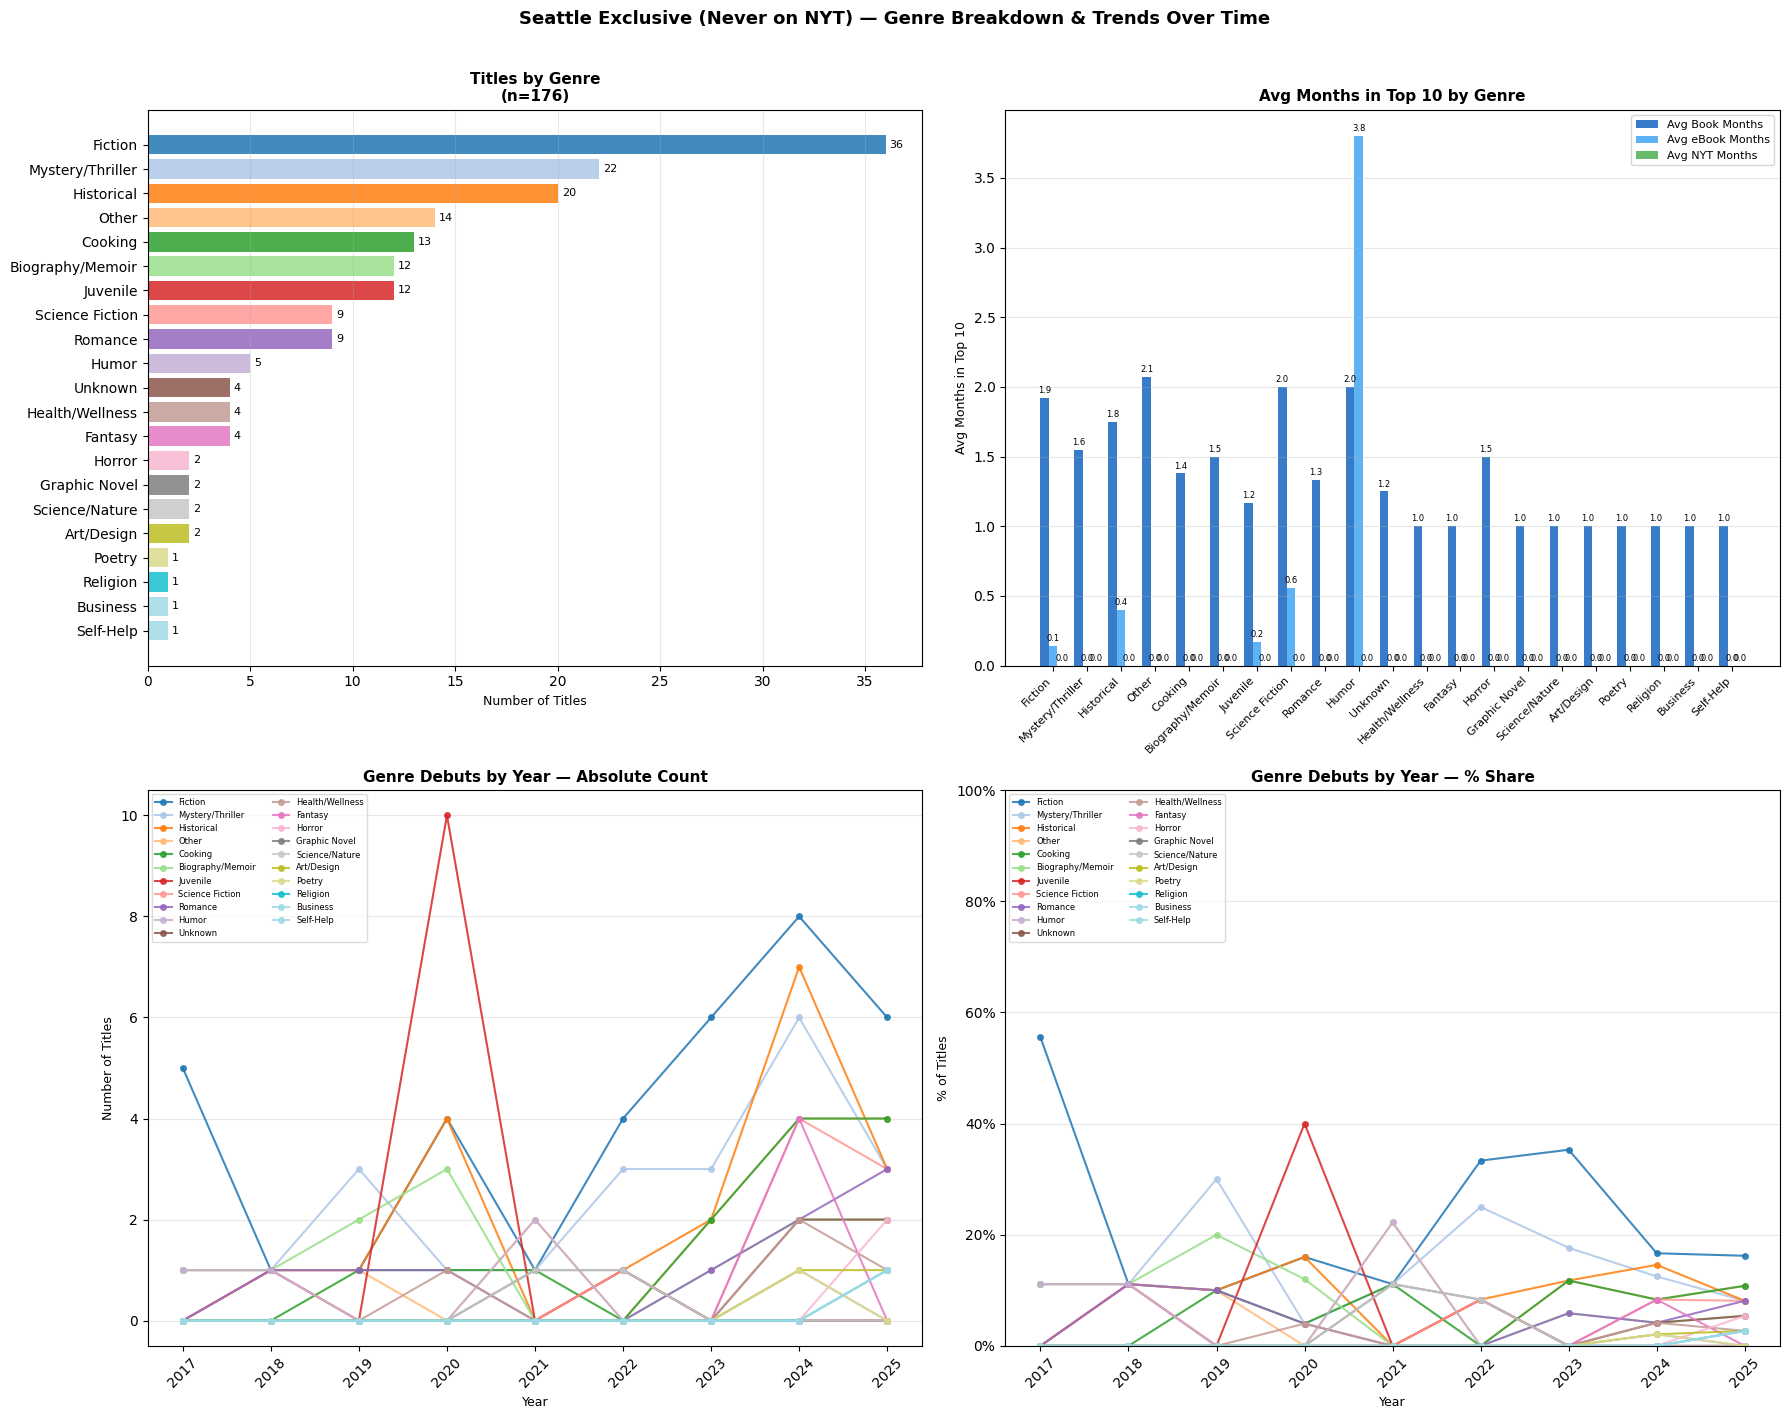

✅ spl_only chart saved

── spl_leads_nyt ── n=23
genre
Fiction             7
Mystery/Thriller    4
Historical          3
Biography/Memoir    2
Fantasy             2
Humor               1
Art/Design          1
Juvenile            1
Science Fiction     1
Religion            1
Name: count, dtype: int64


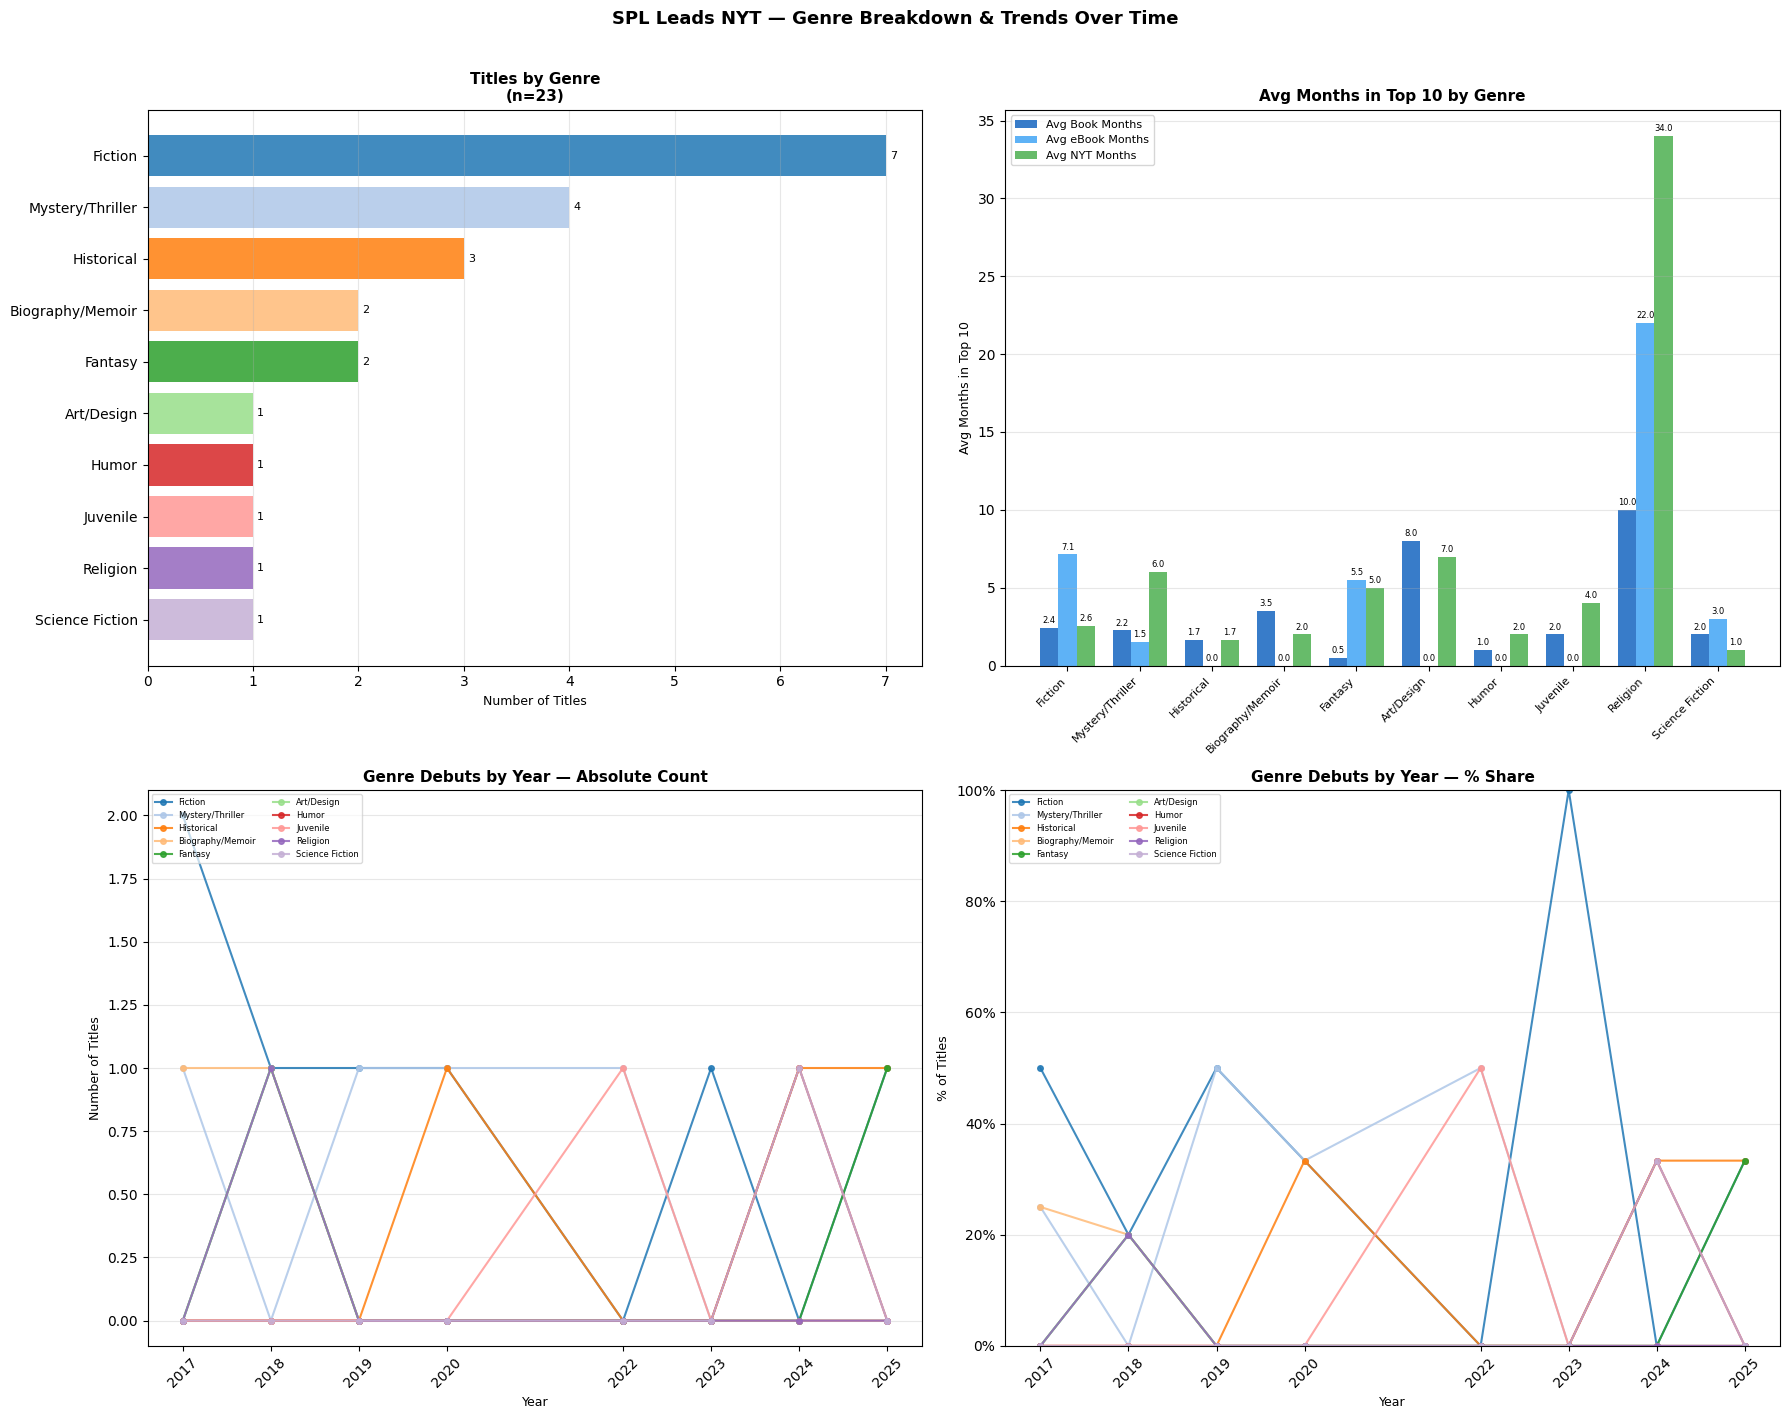

✅ spl_leads_nyt chart saved

── simultaneous ── n=149
genre
Mystery/Thriller    36
Fiction             21
Historical          19
Biography/Memoir    12
Other               11
Romance             10
Science Fiction      7
Cooking              7
Fantasy              6
Art/Design           3
Juvenile             3
Business             3
Humor                2
Science/Nature       2
Self-Help            2
Travel               2
Unknown              1
Poetry               1
Religion             1
Name: count, dtype: int64


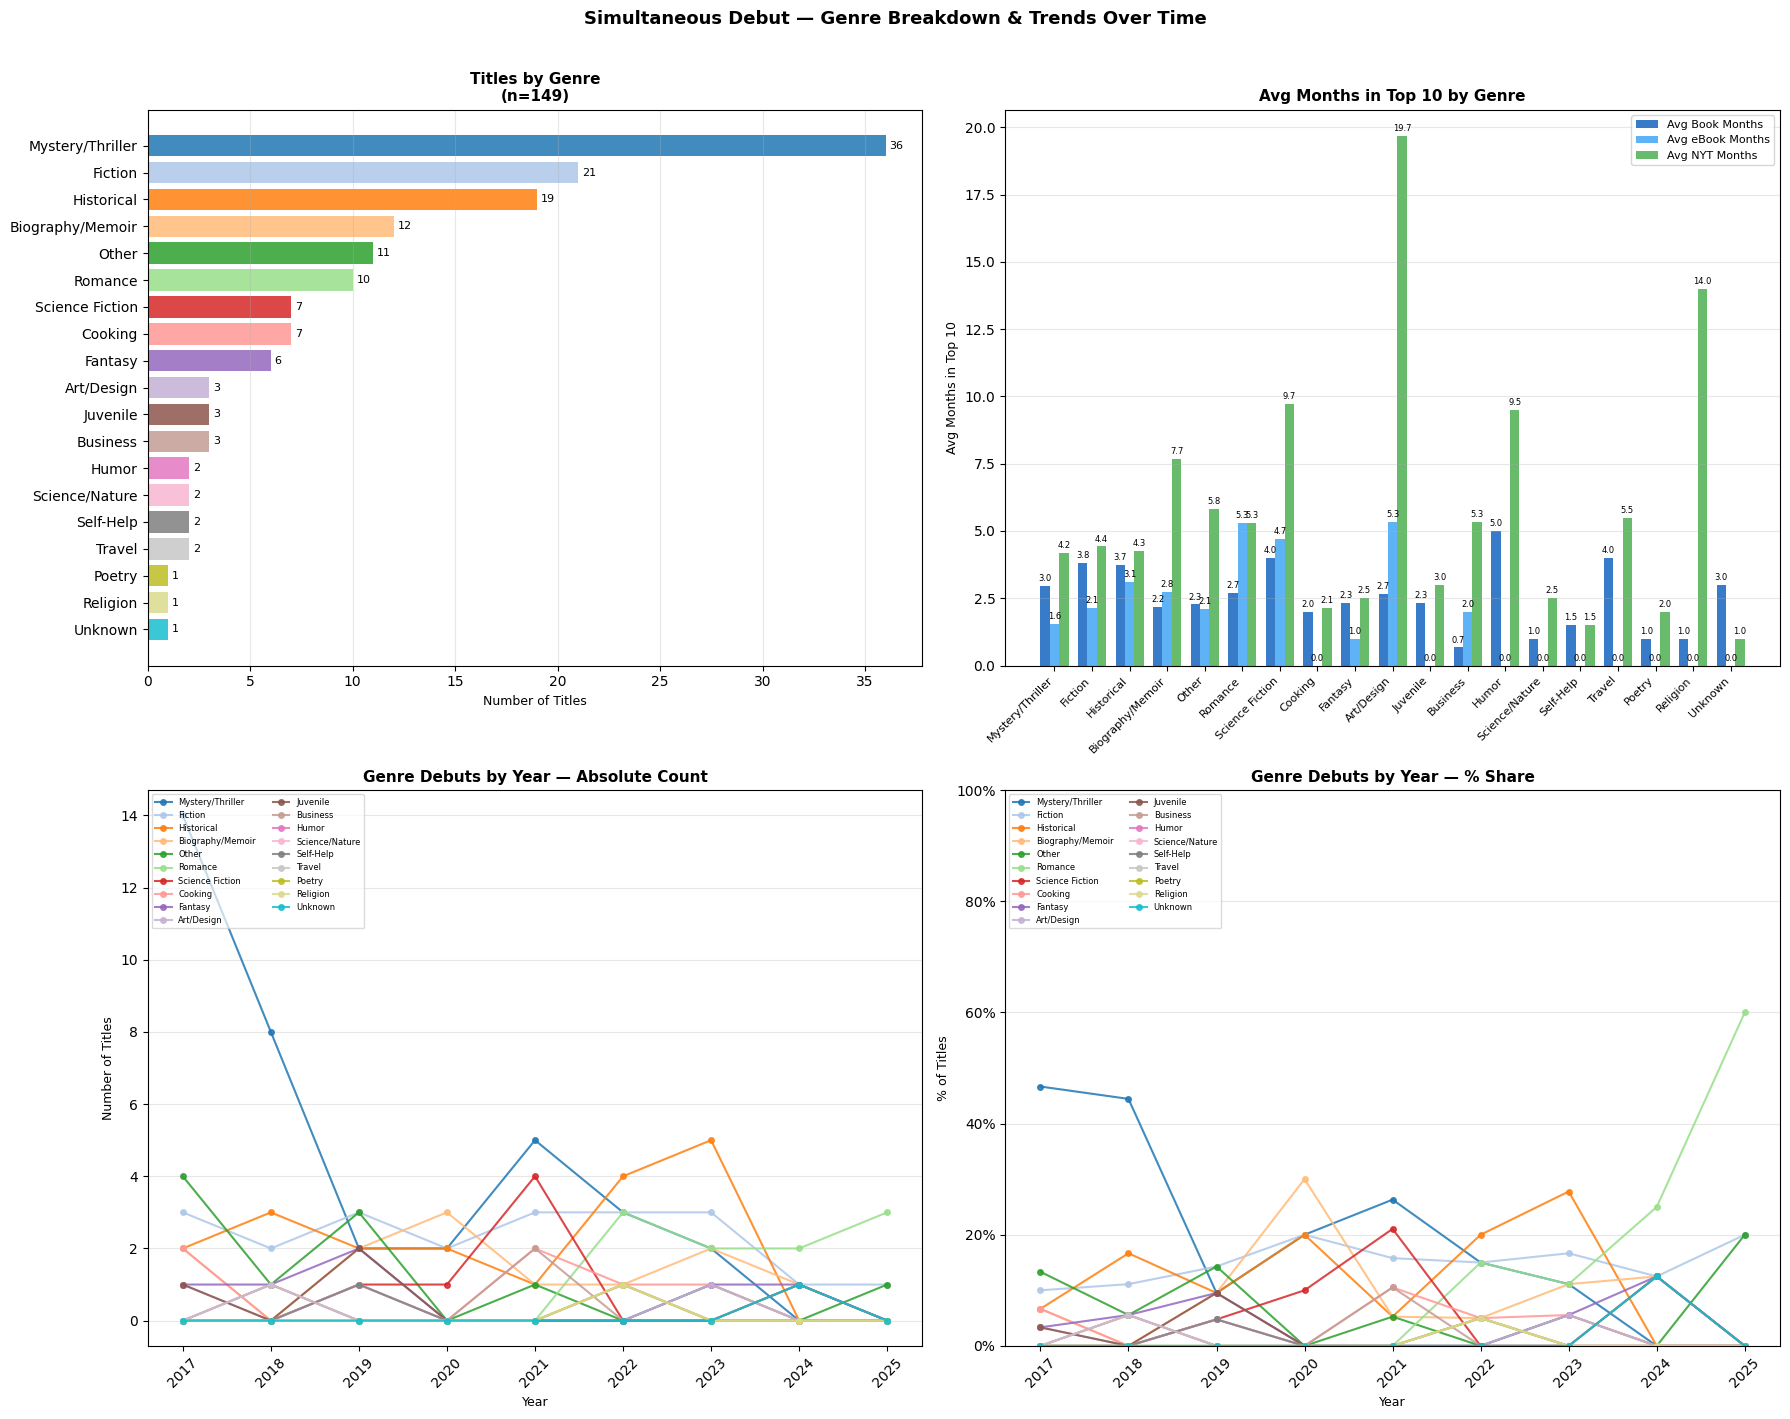

✅ simultaneous chart saved

── nyt_leads_spl ── n=153
genre
Fiction             30
Biography/Memoir    23
Historical          21
Mystery/Thriller    17
Romance             12
Fantasy             12
Other               11
Science Fiction      6
Juvenile             4
Science/Nature       4
Nonfiction           3
Humor                2
Self-Help            2
Cooking              2
Unknown              1
Travel               1
Health/Wellness      1
Art/Design           1
Name: count, dtype: int64


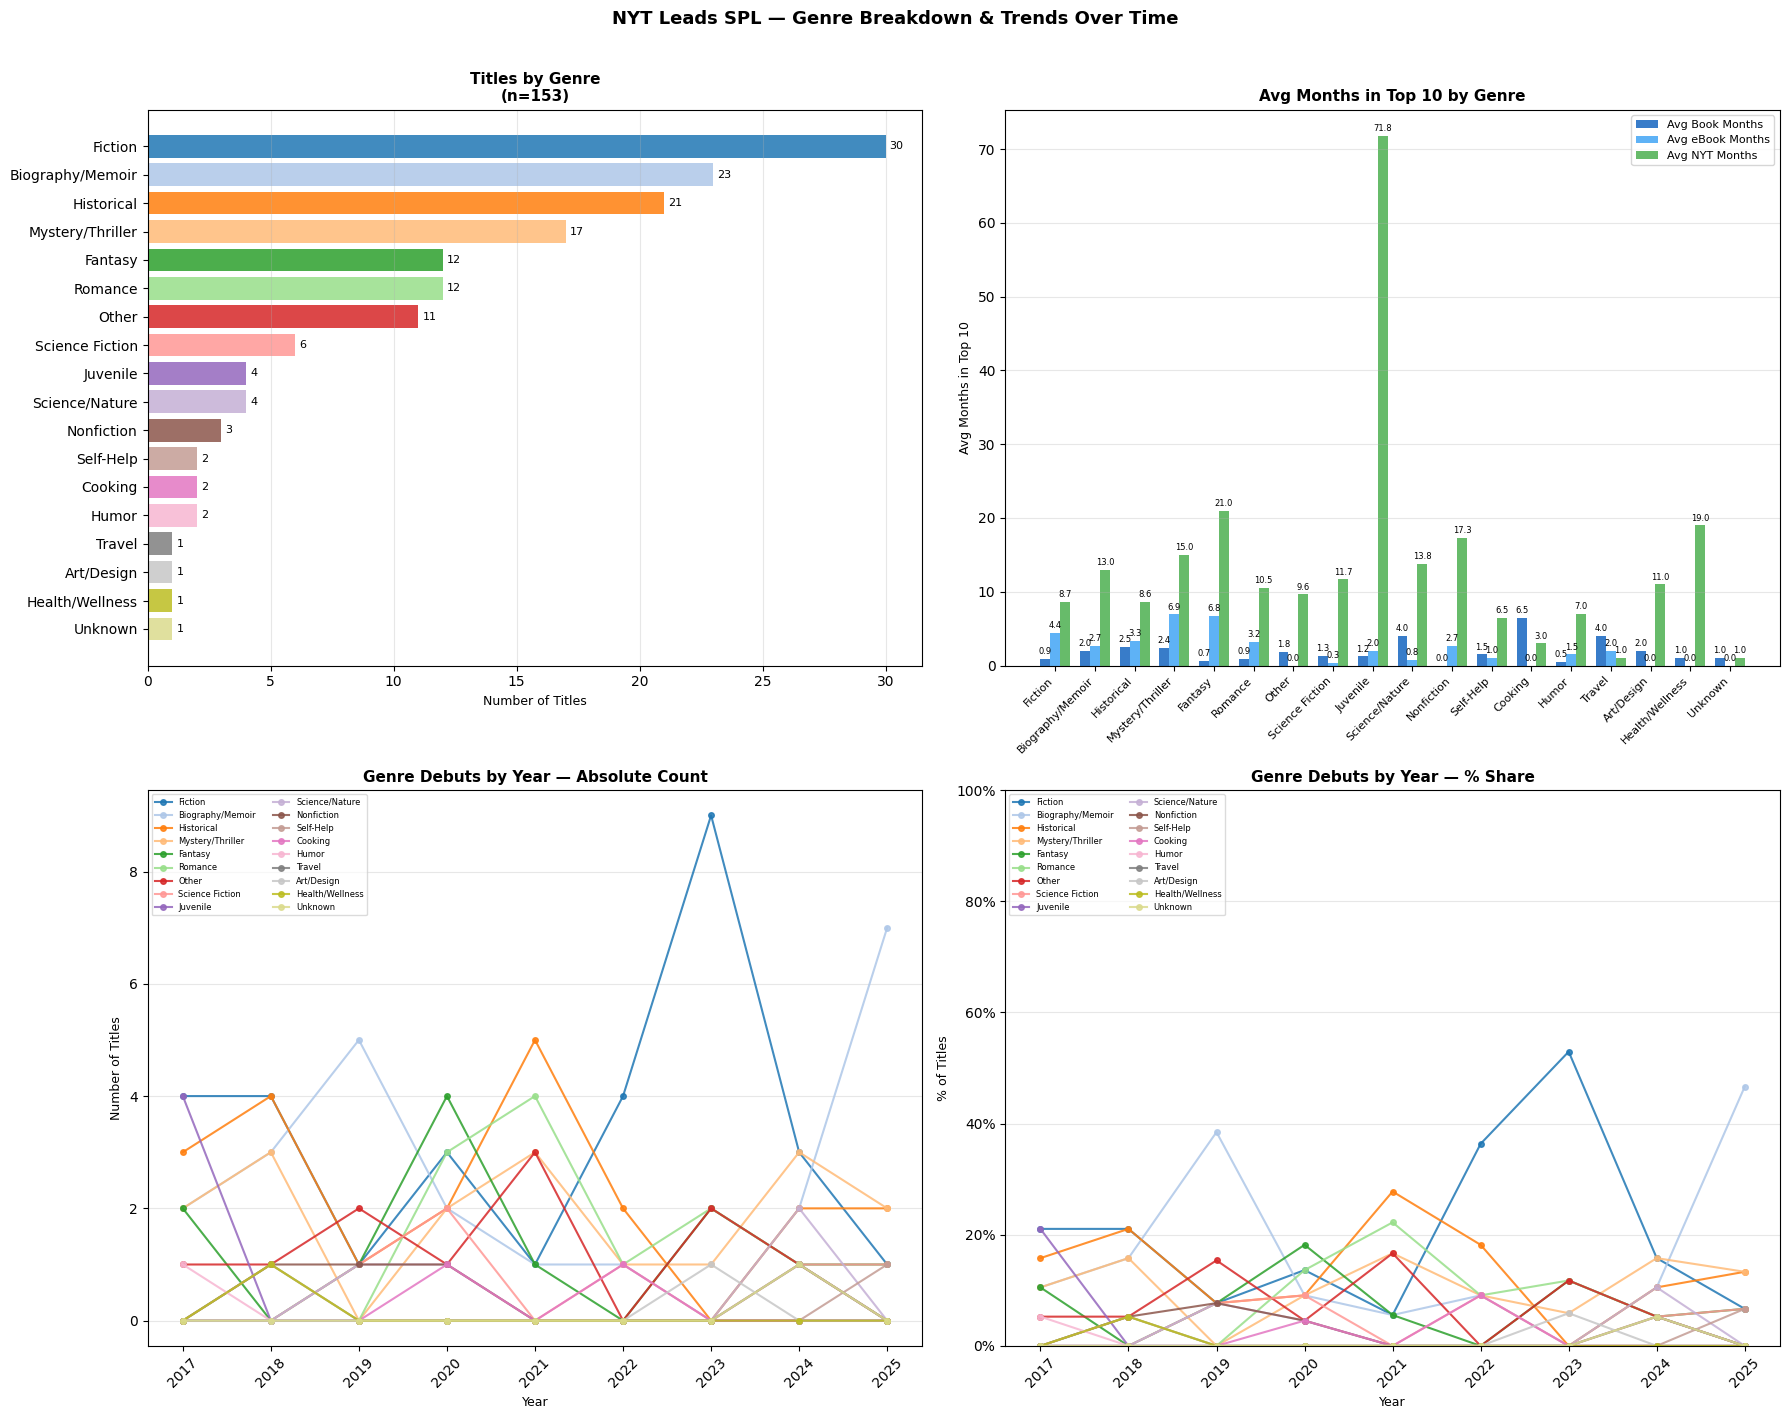

✅ nyt_leads_spl chart saved


In [28]:
# ── build genre longevity and yearly pivot per segment ────────────────────────
segments_to_plot = ['spl_only', 'spl_leads_nyt', 'simultaneous', 'nyt_leads_spl']

segment_titles = {
    'spl_only':      'Seattle Exclusive (Never on NYT)',
    'spl_leads_nyt': 'SPL Leads NYT',
    'simultaneous':  'Simultaneous Debut',
    'nyt_leads_spl': 'NYT Leads SPL',
}

for segment in segments_to_plot:

    seg_df = title_timelines[
        (title_timelines['segment'] == segment) &
        (title_timelines['ref_date'].notna()) &
        (title_timelines['genre'].notna())
    ].copy()

    # add ref_year from ref_date
    seg_df['ref_year'] = seg_df['ref_date'].dt.year

    if seg_df.empty:
        print(f"No data for segment: {segment}")
        continue

    print(f"\n── {segment} ── n={len(seg_df)}")
    print(seg_df['genre'].value_counts())

    # ── summary tables ────────────────────────────────────────────────────────
    genre_longevity = (seg_df
                       .groupby('genre')
                       .agg(
                           n_titles         = ('genre',        'size'),
                           avg_book_months  = ('book_months',  'mean'),
                           avg_ebook_months = ('ebook_months', 'mean'),
                           avg_nyt_months   = ('nyt_months',   'mean'),
                       )
                       .round(2)
                       .reset_index()
                       .sort_values('n_titles', ascending=False))

    # ── yearly genre counts ───────────────────────────────────────────────────
    yearly_genre = (seg_df
                    .groupby(['ref_year', 'genre'])
                    .size()
                    .reset_index(name='n_titles'))

    yearly_genre_pivot = (yearly_genre
                          .pivot(index='ref_year', columns='genre', values='n_titles')
                          .fillna(0))

    # order columns by total count
    col_order = [c for c in genre_longevity['genre'].tolist()
                 if c in yearly_genre_pivot.columns]
    yearly_genre_pivot = yearly_genre_pivot[col_order]

    n_genres  = len(yearly_genre_pivot.columns)
    colors    = plt.cm.tab20(range(n_genres))
    color_map = dict(zip(yearly_genre_pivot.columns, colors))

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # plot 1: title count by genre
    ax1 = axes[0, 0]
    bar_colors = [color_map.get(g, '#999999') for g in genre_longevity['genre']]
    bars = ax1.barh(genre_longevity['genre'], genre_longevity['n_titles'],
                    color=bar_colors, alpha=0.85)
    ax1.bar_label(bars, fmt='%d', fontsize=8, padding=3)
    ax1.set_title(f'Titles by Genre\n(n={len(seg_df)})',
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel('Number of Titles', fontsize=9)
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)

    # plot 2: avg months in top 10 by genre
    ax2 = axes[0, 1]
    x     = range(len(genre_longevity))
    width = 0.25
    bars1 = ax2.bar([i - width for i in x], genre_longevity['avg_book_months'],
                    width, label='Avg Book Months',  color='#1565C0', alpha=0.85)
    bars2 = ax2.bar([i        for i in x], genre_longevity['avg_ebook_months'],
                    width, label='Avg eBook Months', color='#42A5F5', alpha=0.85)
    bars3 = ax2.bar([i + width for i in x], genre_longevity['avg_nyt_months'],
                    width, label='Avg NYT Months',   color='#4CAF50', alpha=0.85)
    for bars_obj in [bars1, bars2, bars3]:
        ax2.bar_label(bars_obj, fmt='%.1f', fontsize=6, padding=2)
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(genre_longevity['genre'], rotation=45, ha='right', fontsize=8)
    ax2.set_title('Avg Months in Top 10 by Genre',
                  fontsize=11, fontweight='bold')
    ax2.set_ylabel('Avg Months in Top 10', fontsize=9)
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)

    # plot 3: yearly genre trend — absolute counts (line)
    ax3 = axes[1, 0]
    for g in yearly_genre_pivot.columns:
        ax3.plot(yearly_genre_pivot.index, yearly_genre_pivot[g],
                 marker='o', label=g, color=color_map[g],
                 linewidth=1.5, markersize=4, alpha=0.85)
    ax3.set_title('Genre Debuts by Year — Absolute Count',
                  fontsize=11, fontweight='bold')
    ax3.set_ylabel('Number of Titles', fontsize=9)
    ax3.set_xlabel('Year', fontsize=9)
    ax3.set_xticks(yearly_genre_pivot.index)
    ax3.tick_params(axis='x', rotation=45)
    ax3.legend(loc='upper left', fontsize=6, framealpha=0.7, ncol=2)
    ax3.grid(axis='y', alpha=0.3)

    # plot 4: yearly genre trend — % share (line)
    ax4 = axes[1, 1]
    yearly_genre_pct = yearly_genre_pivot.div(yearly_genre_pivot.sum(axis=1), axis=0) * 100
    for g in yearly_genre_pct.columns:
        ax4.plot(yearly_genre_pct.index, yearly_genre_pct[g],
                 marker='o', label=g, color=color_map[g],
                 linewidth=1.5, markersize=4, alpha=0.85)
    ax4.set_title('Genre Debuts by Year — % Share',
                  fontsize=11, fontweight='bold')
    ax4.set_ylabel('% of Titles', fontsize=9)
    ax4.set_xlabel('Year', fontsize=9)
    ax4.set_xticks(yearly_genre_pct.index)
    ax4.tick_params(axis='x', rotation=45)
    ax4.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax4.legend(loc='upper left', fontsize=6, framealpha=0.7, ncol=2)
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim(0, 100)

    fig.suptitle(f'{segment_titles[segment]} — Genre Breakdown & Trends Over Time',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{figure_output_dir}/genre_by_segment_{segment}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ {segment} chart saved")

#### What are genres or other literary themes that are popular among SPL readers but not national readers?  Do these titles indicate a unique Seattle reading culture?

In [29]:
# ── SPL only titles since 2024 ────────────────────────────────────────────────
spl_only_2024 = (title_timelines[
    (title_timelines['segment'] == 'spl_only') &
    (title_timelines['ref_yr'] >= 2024)
][['book_title', 'ebook_title', 'genre',
   'book_first_yr', 'book_first_mo',
   'book_peak_rank', 'ebook_peak_rank',
   'book_months', 'ebook_months']]
.copy())

# add author
book_author = (book_ranked[['title', 'creator']]
               .drop_duplicates('title')
               .rename(columns={'title': 'book_title', 'creator': 'author'}))

spl_only_2024 = (spl_only_2024
                 .merge(book_author, on='book_title', how='left')
                 .sort_values(['genre', 'book_first_yr', 'book_first_mo'])
                 [['genre', 'book_title', 'author', 'ebook_title',
                   'book_first_yr', 'book_first_mo',
                   'book_peak_rank', 'book_months']])

print(f"SPL-only titles debuting 2024+: {len(spl_only_2024)}")
print(f"\nBy genre:")
print(spl_only_2024['genre'].value_counts())

# print by genre
pd.set_option('display.max_colwidth', 60)
for genre in spl_only_2024['genre'].value_counts().index:
    subset = spl_only_2024[spl_only_2024['genre'] == genre]
    print(f"\n{'='*60}")
    print(f"  {genre.upper()}  ({len(subset)} titles)")
    print(f"{'='*60}")
    print(subset[['book_title', 'author', 'book_first_yr',
                  'book_first_mo', 'book_peak_rank', 'book_months']]
          .to_string(index=False))

SPL-only titles debuting 2024+: 85

By genre:
genre
Fiction             14
Historical          10
Mystery/Thriller     9
Other                8
Cooking              8
Science Fiction      7
Romance              5
Unknown              4
Fantasy              4
Biography/Memoir     4
Health/Wellness      3
Art/Design           2
Horror               2
Poetry               1
Religion             1
Business             1
Self-Help            1
Humor                1
Name: count, dtype: int64

  FICTION  (14 titles)
                     book_title                      author  book_first_yr  book_first_mo  book_peak_rank  book_months
                  ROMAN STORIES              LAHIRI, JHUMPA         2024.0            1.0             3.0            3
      COME AND GET IT : A NOVEL                 REID, KILEY         2024.0            2.0             1.0            1
BEHIND YOU IS THE SEA : A NOVEL        DARRAJ, SUSAN MUADDI         2024.0            4.0             5.0            2
THE DJIN